In [49]:
# Fixed parameter-space point.
m_dm = 2.636651e-25
eps = 2.335721

T_dm = 300.0
k_B = 1.380649e-23

In [50]:
import constants as c
import numpy as np
import math
import matplotlib.pyplot as plt
import time
import numpy as np
import pandas as pd
import csv
from scipy.stats import maxwell
from scipy.optimize import curve_fit
from scipy.integrate import solve_ivp
from concurrent.futures import ProcessPoolExecutor, as_completed

vk = c.vk
vrf = c.vrf
z_offset = c.z0
z_min_valid = -c.ion_height
z_margin = 1.0e-6   # optional safety margin away from electrode plane
xy1k = c.xy1k
xy2k = c.xy2k
pi = math.pi
um = c.um
cm = c.cm
mm = c.mm
K = c.K
e = c.e
alpha = 1/137.06
d_chain = 3.7066438742e-06  # 3.7 µm separation between ions
delta_ion_2 = 0#-4.9903032463e-14 # small displacement of ion 2
m_ion = c.m 
Z_ion = c.Z
freq_x = 719430.7131391969
freq_y = 3031200.0099101723
freq_z = 3002153.5607483205
omega_vec = np.asarray(2*pi*np.array([freq_x,freq_y,freq_z]), dtype=float) 
hbar = 1.0545718e-34 
mode_y = 2*pi*np.array([3031200.01,2944587.06,2818861.50])
mode_z = 2*pi*np.array([3002153.56,2914677.59,2787603.39])

# Potential/Force Computation
## Compute DC Potential

In [51]:
## From dc_potential.ipynb
## Functions
# (x,y,z) = coordinate of sample
# (xik,yik,z0) = ith corner coordinates of kth electrode
# vk = voltage applied to kth electrode
def potential_term(x,y,z,xik,yik,z0):
    num = (xik-x)*(yik-y); # numerator
    den = (z-z0)*np.sqrt((z-z0)**2+(xik-x)**2+(yik-y)**2); # denominator
    return num/den

def dc_potential_single_electrode(x,y,z,x1k,y1k,x2k,y2k,z0,vk):
    term1 = np.arctan(potential_term(x,y,z,x2k,y2k,z0))
    term2 = np.arctan(potential_term(x,y,z,x1k,y2k,z0))
    term3 = np.arctan(potential_term(x,y,z,x2k,y1k,z0))
    term4 = np.arctan(potential_term(x,y,z,x1k,y1k,z0))
    return (vk/(2*math.pi))*(term1-term2-term3+term4)

def dc_potential_total(x,y,z,xy1k=c.xy1k,xy2k=c.xy2k,z0=c.z0,vk=c.vk):
    # extract individual (xik,yik),vk values from array
    # all arrays must be same size
    # sum potentials from all electrodes
    # Allow x, y, and z to be either scalars or same-shaped arrays.
    x, y, z = np.broadcast_arrays(
        np.asarray(x, dtype=float),
        np.asarray(y, dtype=float),
        np.asarray(z, dtype=float),
    )
    z = z+c.ion_height # account for ion height
    pot = np.zeros_like(x, dtype=float)
    for i in range (0,len(c.vk)):
        x1k = xy1k[i][0]
        y1k = xy1k[i][1]
        x2k = xy2k[i][0]
        y2k = xy2k[i][1]
        v = vk[i]
        if(i==19 or i==39): # make sure Q39-40 are on the M4 layer
            new_pot = dc_potential_single_electrode(x,y,z,x1k,y1k,x2k,y2k,0,v); # z0=0 for Q39-40
        else:
            new_pot = dc_potential_single_electrode(x,y,z,x1k,y1k,x2k,y2k,z0,v); # z0 = -11.8um for Q1-38
        pot+=new_pot
    return pot

## Compute RF Potential

In [52]:
## From rf_potential.ipynb
## Functions
## Compute Pseudopotential (J)
"""
# Method 1: numerical RF gradient
Ex,Ey,Ez = np.gradient(-1*phi_rf,res,res,res); # Electric field components
E_squared = Ex**2+Ey**2+Ez**2; # Electric field strength squared
pseudo2 = (c.Z**2*c.e**2)/(4*c.m*c.omega**2)*E_squared
# pseudo_reshaped = pseudo.reshape(int(2*x_max/res+1),-1)
"""
# Method 2: analytical RF gradient
def divatan(up,down):
    #This is d(arctan2(up,down))/ddown up to a minus sign. It's useful for the pseudo-potential
    return up/(up**2+down**2)
def divatanup(up,down):
    #This is d(divatan(up,down))/dup
    return (down**2-up**2)/(up**2+down**2)**2
def divatandown(up,down):
    #This is d(divatan(up,down))/ddown
    return -2*up*down/(up**2+down**2)**2
def pseudopotential(x,y,z,m,Z,q=c.e,omrf=c.omega,VRF=c.vrf,ymin=c.y11,yedge1=c.y21,yedge2=c.y12,ymax=c.y22):
    #this is the pseudo potential, which is Z^2*(Div[PhiRF]/cos(om*t))^2/(4m*omega^2)
    x, y, z = np.broadcast_arrays(
        np.asarray(x, dtype=float),
        np.asarray(y, dtype=float),
        np.asarray(z, dtype=float),
    )
    z = z+c.ion_height # account for ion height
    divypart=divatan(z,yedge2-y)-divatan(z,yedge1-y)+divatan(z,ymin-y)-divatan(z,ymax-y)
    divzpart=divatan(yedge2-y,z)-divatan(yedge1-y,z)+divatan(ymin-y,z)-divatan(ymax-y,z)
    return ((Z**2*q**2)/(4*m*omrf**2)) * (VRF/math.pi)**2 * (divypart**2+divzpart**2)

In [53]:
## Compute Full Potential Energy
def coulomb_pot(x,y,z,eps,Z=c.Z):
    x, y, z = np.broadcast_arrays(
        np.asarray(x, dtype=float),
        np.asarray(y, dtype=float),
        np.asarray(z, dtype=float),
    )
    return c.K*eps*Z*c.e**2/np.sqrt(x**2+y**2+z**2)
    
def potential_energy(xyz, m_dm, eps, component="total"):
    """
    Compute potential energy for either one point or many points.
    Accepted input shapes
    ---------------------
    xyz.shape == (3,)
        Returns a scalar for a single component.
    xyz.shape == (n, 3)
        Returns an array of shape (n,) for a single component.
    """
    xyz = np.asarray(xyz, dtype=float)
    single_input = False
    if xyz.ndim == 1:
        if xyz.shape != (3,):
            raise ValueError(
                "A single position must have shape (3,)"
            )
        xyz = xyz.reshape(1, 3)
        single_input = True
    elif xyz.ndim != 2 or xyz.shape[1] != 3:
        raise ValueError(
            "xyz must have shape (3,) or (n, 3)"
        )
    x = xyz[:, 0]
    y = xyz[:, 1]
    z = xyz[:, 2]
    dc = eps * c.e * dc_potential_total(x, y, z)
    pseudo_rf = pseudopotential(
        x,
        y,
        z,
        m_dm,
        eps,
    )
    coulomb = coulomb_pot(
        x,
        y,
        z,
        eps,
    )
    if component == "dc":
        out = dc
    elif component == "pseudo_rf":
        out = pseudo_rf
    elif component == "coulomb":
        out = coulomb
    elif component == "trap":
        out = dc + pseudo_rf
    elif component == "total":
        out = dc + pseudo_rf + coulomb
    elif component == "all":
        if single_input:
            return (
                float(dc[0]),
                float(pseudo_rf[0]),
                float(coulomb[0]),
            )
        return dc, pseudo_rf, coulomb
    else:
        raise ValueError(
            f"Unknown potential component: {component}"
        )
    if single_input:
        return float(out[0])
    return np.asarray(out, dtype=float)

## Compute RF/DC Force

In [54]:
"""
xyz : ndarray, shape (n, 3)
        Particle positions.
"""
# RF pseudo-force
def FRF(xyz,m,Z,q=c.e,omrf=c.omega,VRF=c.vrf,ymin=c.y11,yedge1=c.y21,yedge2=c.y12,ymax=c.y22):
    xyz = np.asarray(xyz, dtype=float)
    if xyz.ndim != 2 or xyz.shape[1] != 3:
        raise ValueError("xyz must have shape (n, 3)")
    x = xyz[:, 0]
    y = xyz[:, 1]
    z = xyz[:, 2] + c.ion_height # Take into account ion height
    m = float(np.asarray(m).ravel()[0])
    Z = float(np.asarray(Z).ravel()[0])
    q = float(np.asarray(q).ravel()[0])
    omrf = float(np.asarray(omrf).ravel()[0])
    VRF = float(np.asarray(VRF).ravel()[0])
    #this is the pseudo potential, which is Z^2*(Div[PhiRF]/cos(om*t))^2/(4m*omega^2)
    divypart=divatan(z,yedge2-y)-divatan(z,yedge1-y)+divatan(z,ymin-y)-divatan(z,ymax-y)
    divzpart=divatan(yedge2-y,z)-divatan(yedge1-y,z)+divatan(ymin-y,z)-divatan(ymax-y,z) 
    divyparty=-2*divypart*(divatandown(z,yedge2-y)-divatandown(z,yedge1-y)+divatandown(z,ymin-y)-divatandown(z,ymax-y)) 
    divypartz=2*divypart*(divatanup(z,yedge2-y)-divatanup(z,yedge1-y)+divatanup(z,ymin-y)-divatanup(z,ymax-y)) 
    divzparty=-2*divzpart*(divatanup(yedge2-y,z)-divatanup(yedge1-y,z)+divatanup(ymin-y,z)-divatanup(ymax-y,z)) 
    divzpartz=2*divzpart*(divatandown(yedge2-y,z)-divatandown(yedge1-y,z)+divatandown(ymin-y,z)-divatandown(ymax-y,z)) 
    return -1*((VRF*Z*q)/(2*pi*np.sqrt(m)*omrf))**2*np.column_stack([divypartz*0, divzparty+divyparty, divzpartz+divypartz])

# DC force
def divatan(up,down):
    #This is d(arctan2(up,down))/ddown up to a minus sign. It's useful for the pseudo-potential
    return up/(up**2+down**2)
def divatanup(up,down):
    #This is d(divatan(up,down))/dup
    return (down**2-up**2)/(up**2+down**2)**2
def divatandown(up,down):
    #This is d(divatan(up,down))/ddown
    return -2*up*down/(up**2+down**2)**2

def anatangrad(xi,yi,xyz,v): # gradient term of DC potential
    xyz = np.asarray(xyz, dtype=float)
    x = xyz[:, 0]
    y = xyz[:, 1]
    z = xyz[:, 2]
    dy=y-yi
    dx=x-xi
    r = np.sqrt(dx**2+dy**2+z**2); # added distance
    dry2=z**2+dy**2
    drx2=z**2+dx**2
    divy=z*dx/(r*dry2); # divide by factor r
    divz=-dy*dx*(1/dry2+1/drx2)/r; # divide by factor r
    divx=z*dy/(r*drx2); # divide by factor r
    return (v/(2*np.pi))*np.column_stack([divx, divy, divz])

def FDC_single(x1,y1,x2,y2,xyz,v,Z,q=c.e):
    return -Z*q * (anatangrad(x2,y2,xyz,v)-anatangrad(x2,y1,xyz,v)-anatangrad(x1,y2,xyz,v)+anatangrad(x1,y1,xyz,v))

def FDC(xyz, m, Z, q=c.e, omrf=c.omega,
        ymin=c.y11, yedge1=c.y21, yedge2=c.y12, ymax=c.y22):
    xyz = np.asarray(xyz, dtype=float)
    if xyz.ndim != 2 or xyz.shape[1] != 3:
        raise ValueError("xyz must have shape (n, 3)")
    z_original = xyz[:, 2].copy() + c.ion_height # Take into account ion height
    force = np.zeros_like(xyz)
    for k in range(0, 40):
        xyz_k = xyz.copy()
        if (k != 19 and k != 39):
            xyz_k[:, 2] = z_original - z_offset  # keep scalar math
        else:
            xyz_k[:, 2] = z_original
        (x1k, y1k) = xy1k[k]
        (x2k, y2k) = xy2k[k]
        # enforce scalar on vk[k]
        v_k = float(np.asarray(vk[k]).ravel()[0])
        force_single = FDC_single(x1k, y1k, x2k, y2k, xyz_k, v_k, Z, q=q)
        # check shape of force_single 
        force_single = np.asarray(force_single, dtype=float)
        if force_single.shape != xyz.shape:
            raise ValueError(
                f"FDC_single returned unexpected shape {force_single.shape}; "
                f"expected {xyz.shape} at k={k}"
            )
        force += force_single
    return force

def force(xyz, m_dm, eps, component="total"):
    xyz = np.asarray(xyz, dtype=float)

    single_input = False
    if xyz.ndim == 1:
        xyz = xyz.reshape(1, 3)
        single_input = True

    if xyz.ndim != 2 or xyz.shape[1] != 3:
        raise ValueError("xyz must have shape (n, 3) or (3,)")

    dc_force = FDC(xyz, m_dm, eps)
    pseudo_force = FRF(xyz, m_dm, eps)

    r = np.linalg.norm(xyz, axis=1)

    coulomb_force = np.full_like(xyz, np.nan, dtype=float)
    good = r > 0

    coulomb_force[good] = (
        c.K * c.Z * eps * c.e**2
        * xyz[good]
        / r[good, None]**3
    )

    if component == "dc":
        out = dc_force
    elif component == "pseudo_rf":
        out = pseudo_force
    elif component == "coulomb":
        out = coulomb_force
    elif component == "trap":
        out = dc_force + pseudo_force
    elif component == "total":
        out = dc_force + pseudo_force + coulomb_force
    elif component == "all":
        return dc_force, pseudo_force, coulomb_force
    else:
        raise ValueError(f"Unknown force component: {component}")

    if single_input:
        return out[0]

    return out

In [55]:
def xyz_on_sphere(n, radius, center=(0.0, 0.0, 0.0)):
    """
    Generate positions evenly distributed on the surface of a sphere.

    Parameters
    ----------
    n_dm : int
        Number of coordinate points.
    radius : float
        Sphere radius in meters.
    center : array-like, shape (3,)
        Sphere center in meters.
    
    Returns
    -------
    x0_dms : ndarray, shape (n_dm, 3)
        Positions on the sphere surface.
    """

    center = np.asarray(center, dtype=float)
    if n <= 0:
        raise ValueError("n_dm must be positive")
    indices = np.arange(n)
    golden_angle = np.pi * (3.0 - np.sqrt(5.0))
    z = 1.0 - 2.0 * (indices + 0.5) / n
    r_xy = np.sqrt(1.0 - z**2)
    theta = golden_angle * indices
    x = r_xy * np.cos(theta)
    y = r_xy * np.sin(theta)
    points = np.column_stack([x, y, z])
    x0_dms = center + radius * points
    return x0_dms

def valid_xyz_mask(xyz):
    xyz = np.asarray(xyz, dtype=float)
    return xyz[..., 2] > (z_min_valid + z_margin)

def xyz_on_valid_sphere(n, radius, center=(0.0, 0.0, 0.0)):
    xyz = xyz_on_sphere(n, radius, center=center)
    mask = valid_xyz_mask(xyz)
    return xyz[mask]

def valid_fraction_on_sphere(n, radius):
    xyz = xyz_on_sphere(n, radius)
    return np.mean(valid_xyz_mask(xyz))

def PE_on_sphere(
    n,
    radius,
    m_dm,
    eps,
    component="total",
):
    xyz = xyz_on_valid_sphere(n, radius)
    if xyz.shape[0] == 0:
        return np.array([], dtype=float)
    return np.asarray(
        potential_energy(
            xyz,
            m_dm,
            eps,
            component=component,
        ),
        dtype=float,
    )

def force_on_sphere(
    n,
    radius,
    m_dm,
    eps,
    component="total",
):
    xyz = xyz_on_valid_sphere(n, radius)
    if xyz.shape[0] == 0:
        return np.empty((0, 3), dtype=float)
    return np.asarray(
        force(
            xyz,
            m_dm,
            eps,
            component=component,
        ),
        dtype=float,
    )

def deterministic_MB_speeds(T, m_dm, quantile):
    k_B = 1.380649e-23
    scale = np.sqrt(k_B * T / m_dm)
    speeds = maxwell.ppf(quantile, scale=scale)
    return speeds

# Check Functionality
## Proper Vectorization

In [56]:
test_xyz = np.array([
    [100.0e-6, 0.0, 100.0e-6],
    [200.0e-6, 0.0, 100.0e-6],
    [300.0e-6, 0.0, 100.0e-6],
])

U_vectorized = potential_energy(
    test_xyz,
    m_dm,
    eps,
    component="trap",
)

U_scalar = np.array([
    potential_energy(
        point,
        m_dm,
        eps,
        component="trap",
    )
    for point in test_xyz
])

print("Vectorized:", U_vectorized)
print("Scalar:    ", U_scalar)
print(
    "Match:",
    np.allclose(
        U_vectorized,
        U_scalar,
        equal_nan=True,
    ),
)

Vectorized: [1.53391700e-19 1.52284870e-19 1.41273589e-19]
Scalar:     [1.53391700e-19 1.52284870e-19 1.41273589e-19]
Match: True


## Consistency of Potential vs Force

In [57]:
m_dm = 2.636651e-25
eps = 2.335721

def numerical_force_from_potential(xyz, m_dm, eps, component, h=0.05e-6):
    xyz = np.asarray(xyz, dtype=float)

    if xyz.shape != (3,):
        raise ValueError("xyz must have shape (3,)")

    F = np.zeros(3)

    for k in range(3):
        step = np.zeros(3)
        step[k] = h

        xyz_plus = xyz + step
        xyz_minus = xyz - step

        # Avoid finite-difference points outside valid potential domain.
        if xyz_plus[2] <= z_min_valid + z_margin:
            F[k] = np.nan
            continue

        if xyz_minus[2] <= z_min_valid + z_margin:
            F[k] = np.nan
            continue

        U_plus = potential_energy(xyz_plus, m_dm, eps, component)
        U_minus = potential_energy(xyz_minus, m_dm, eps, component)

        F[k] = -(U_plus - U_minus) / (2.0 * h)

    return F


test_points = [
    np.array([0.0, 0.0, 1e-6]),
    np.array([0.0, 0.0, 10e-6]),
    np.array([10e-6, 0.0, 10e-6]),
    np.array([0.0, 10e-6, 10e-6]),
    np.array([0.0, 0.0, 100e-6]),
    np.array([100e-6, 0.0, 300e-6]),
]

for xyz in test_points:
    if xyz[2] <= z_min_valid + z_margin:
        continue

    print()
    print("xyz =", xyz)

    for component in ["dc", "pseudo_rf", "coulomb", "trap", "total"]:
        F_analytic = np.asarray(force(xyz, m_dm, eps, component), dtype=float).reshape(3)
        F_numeric = numerical_force_from_potential(xyz, m_dm, eps, component)

        diff = F_analytic - F_numeric

        denom = max(
            np.linalg.norm(F_analytic),
            np.linalg.norm(F_numeric),
            1e-300,
        )

        rel_err = np.linalg.norm(diff) / denom

        print(component)
        print("  analytic:", F_analytic)
        print("  numeric :", F_numeric)
        print("  diff    :", diff)
        print("  rel_err :", rel_err)


xyz = [0.e+00 0.e+00 1.e-06]
dc
  analytic: [ 6.73979184e-31  3.72860037e-31 -7.17730913e-17]
  numeric : [ 1.80555932e-28  1.20370622e-28 -7.17731757e-17]
  diff    : [-1.79881953e-28 -1.19997761e-28  8.43569399e-23]
  rel_err : 1.1753268411492e-06
pseudo_rf
  analytic: [-0.00000000e+00 -0.00000000e+00 -5.81092897e-16]
  numeric : [-0.00000000e+00 -0.00000000e+00 -5.81062851e-16]
  diff    : [ 0.00000000e+00  0.00000000e+00 -3.00458659e-20]
  rel_err : 5.1705787699036234e-05
coulomb
  analytic: [0.00000000e+00 0.00000000e+00 5.52123756e-16]
  numeric : [-0.00000000e+00 -0.00000000e+00  5.53507524e-16]
  diff    : [ 0.00000000e+00  0.00000000e+00 -1.38376881e-18]
  rel_err : 0.002499999999999438
trap
  analytic: [ 6.73979184e-31  3.72860037e-31 -6.52865988e-16]
  numeric : [ 1.80555932e-28  1.20370622e-28 -6.52836026e-16]
  diff    : [-1.79881953e-28 -1.19997761e-28 -2.99615090e-20]
  rel_err : 4.5892280421474074e-05
total
  analytic: [ 6.73979184e-31  3.72860037e-31 -1.00742232e-16]


# Full Simulation Code

## Original

In [58]:
def run_simulation_many_dm_single_ion(
    x0_dms, v0_dms, x0_ion, v0_ion,
    t_span, rtol, atol, dt, m_dm, eps, run_rutherford
):
    """
    Run a single-ion / many-DM trajectory simulation.

    This version includes:
        - one trapped ion near the origin
        - many DM particles
        - ion-DM Coulomb forces
        - no DM-DM Coulomb forces

    Parameters
    ----------
    x0_dms : array-like, shape (n_dm, 3)
        Initial positions of the DM particles.

    v0_dms : array-like, shape (n_dm, 3)
        Initial velocities of the DM particles.

    x0_ion : array-like, shape (3,)
        Initial position of the single ion.

    v0_ion : array-like, shape (3,)
        Initial velocity of the single ion.

    t_span : tuple (t_start, t_end)
        Start and end time of the integration.

    dt : float
        Time increment used to build the evaluation grid.

    m_dm : float
        Mass of DM particles in kg.
    
    eps : float
        Charge of DM particles in units of elementary charge.

    run_rutherford : bool
        If True, set trap fields to zero for Rutherford scattering comparison.

    Returns
    -------
    t_eval : ndarray, shape (N,)
        Times at which the solution was evaluated.

    x_ion_sol : ndarray, shape (3, N)
        Ion position trajectory.

    v_ion_sol : ndarray, shape (3, N)
        Ion velocity trajectory.

    x_dms_sol : ndarray, shape (n_dm, 3, N)
        DM position trajectories.

    v_dms_sol : ndarray, shape (n_dm, 3, N)
        DM velocity trajectories.
    """

    x0_dms = np.asarray(x0_dms, dtype=float)
    v0_dms = np.asarray(v0_dms, dtype=float)
    x0_ion = np.asarray(x0_ion, dtype=float)
    v0_ion = np.asarray(v0_ion, dtype=float)

    if x0_dms.ndim != 2 or x0_dms.shape[1] != 3:
        raise ValueError("x0_dms must have shape (n_dm, 3)")

    if v0_dms.shape != x0_dms.shape:
        raise ValueError("v0_dms must have the same shape as x0_dms")

    if x0_ion.shape != (3,):
        raise ValueError("x0_ion must have shape (3,)")

    if v0_ion.shape != (3,):
        raise ValueError("v0_ion must have shape (3,)")

    n_dm = x0_dms.shape[0]

    # The single ion is trapped about the origin.
    r_ion_eq = np.zeros(3, dtype=float)

    def rhs_unified(t, U, r_ion_eq, use_harmonic_ion=True):
        """
        State vector layout:

        U = [
            x_ion(3),
            x_dms(3*n_dm),
            v_ion(3),
            v_dms(3*n_dm)
        ]
        """

        idx0 = 0
        idx1 = idx0 + 3
        idx2 = idx1 + 3 * n_dm
        idx3 = idx2 + 3
        idx4 = idx3 + 3 * n_dm

        x_ion = U[idx0:idx1]
        x_dms = U[idx1:idx2].reshape((n_dm, 3))

        v_ion = U[idx2:idx3]
        v_dms = U[idx3:idx4].reshape((n_dm, 3))

        dx_iondt = v_ion
        dx_dmsdt = v_dms

        dv_iondt = np.zeros(3)
        dv_dmsdt = np.zeros((n_dm, 3))

        # --------------------------------------------------
        # Trap force acting on ion
        # --------------------------------------------------
        if use_harmonic_ion:
            if run_rutherford:
                dv_iondt += np.zeros(3)
            else:
                dv_iondt += -omega_vec**2 * (x_ion - r_ion_eq)
        else:
            if not run_rutherford:
                x_ion_arr = x_ion[None, :]
                F_dc_ion = FDC(x_ion_arr, m=m_ion, Z=Z_ion)[0]
                F_rf_ion = FRF(x_ion_arr, m=m_ion, Z=Z_ion)[0]
                F_ion = F_dc_ion + F_rf_ion
                dv_iondt += F_ion / m_ion

        # --------------------------------------------------
        # Trap force acting on each DM particle
        # --------------------------------------------------
        if not run_rutherford:
            F_dc_dms = FDC(x_dms, m_dm, eps)
            F_rf_dms = FRF(x_dms, m_dm, eps)

            dv_dmsdt += (F_dc_dms + F_rf_dms) / m_dm

        # --------------------------------------------------
        # Coulomb interactions: ion <-> each DM particle
        #
        # No DM-DM Coulomb forces are included.
        # --------------------------------------------------
        delta = x_ion[None, :] - x_dms
        r = np.linalg.norm(delta, axis=1)

        forces = K * Z_ion * eps * e**2 * delta / r[:, None]**3

        # Force on ion due to DM k
        dv_iondt += forces.sum(axis=0) / m_ion

        # Equal and opposite force on DM k due to ion
        dv_dmsdt -= forces / m_dm

        return np.concatenate([
            dx_iondt,
            dx_dmsdt.flatten(),
            dv_iondt,
            dv_dmsdt.flatten()
        ])

    print("Number of DM particles:", n_dm)
    print("Initial ion position:", x0_ion)
    print("Initial ion velocity:", v0_ion)
    if(x0_dms.shape==(1,3)):
        print("Initial DM position:", x0_dms)
        print("Initial DM velocity:", v0_dms)

    # Initial state
    U0 = np.concatenate([
        x0_ion,
        x0_dms.flatten(),
        v0_ion,
        v0_dms.flatten()
    ]).astype(float)

    # Time grid
    t_eval = np.arange(t_span[0], t_span[1], dt)

    # Solve
    sol = solve_ivp(
        rhs_unified,
        t_span,
        U0,
        method="DOP853",
        t_eval=t_eval,
        dense_output=True,
        rtol=rtol,
        atol=atol,
        max_step=dt,
        args=(r_ion_eq,)
    )

    print("Success?", sol.success)
    print("Message:", sol.message)

    if sol.t.size > 0:
        print("Final time:", sol.t[-1])

    # Extract solution
    idx0 = 0
    idx1 = idx0 + 3
    idx2 = idx1 + 3 * n_dm
    idx3 = idx2 + 3
    idx4 = idx3 + 3 * n_dm

    x_ion_sol = sol.y[idx0:idx1]
    x_dms_flat_sol = sol.y[idx1:idx2]

    v_ion_sol = sol.y[idx2:idx3]
    v_dms_flat_sol = sol.y[idx3:idx4]

    # Convert flattened DM solution into shape (n_dm, 3, N)
    n_t = sol.y.shape[1]

    x_dms_sol = x_dms_flat_sol.reshape((n_dm, 3, n_t))
    v_dms_sol = v_dms_flat_sol.reshape((n_dm, 3, n_t))

    return t_eval, x_ion_sol, v_ion_sol, x_dms_sol, v_dms_sol

In [59]:
def analyze_simulation_results(x0_dms, v0_dms, x0_ion, v0_ion, t_span, dt, t_min, m_dm, eps, fit_curve, rutherford, show_plots,
                                rtol, atol):
    # default rtol=1e-13, atol=1e-16
    if(rutherford):
        t00, xion00, vion00, xdms00, vdms00 = run_simulation_many_dm_single_ion(x0_dms, v0_dms, x0_ion, v0_ion, t_span, rtol,atol,dt, m_dm, eps, run_rutherford=True)
    else:
        t00, xion00, vion00, xdms00, vdms00 = run_simulation_many_dm_single_ion(x0_dms, v0_dms, x0_ion, v0_ion, t_span, rtol,atol,dt, m_dm, eps, run_rutherford=False)
    t0 = t00/um
    xion0 = xion00/um
    vion0 = vion00
    xdms0 = xdms00/um
    vdms0 = vdms00
    x0_ion1, y0_ion1, z0_ion1 = xion0[0], xion0[1], xion0[2] # motion of center ion
    d_dms = np.linalg.norm(xdms0, axis=1) # for DM

    ## Plots 
    if(show_plots):

        # -------------------------
        # Ion coordinates vs time
        # -------------------------
        plt.figure(figsize=(18, 5))

        plt.subplot(1, 3, 1)
        plt.plot(t0, x0_ion1, label="x ion")
        plt.xlabel("t (us)")
        plt.ylabel("x (um)")
        plt.title("Ion x-position vs time")
        plt.legend()

        plt.subplot(1, 3, 2)
        plt.plot(t0, y0_ion1, label="y ion")
        plt.xlabel("t (us)")
        plt.ylabel("y (um)")
        plt.title("Ion y-position vs time")
        plt.legend()

        plt.subplot(1, 3, 3)
        plt.plot(t0, z0_ion1, label="z ion")
        plt.xlabel("t (us)")
        plt.ylabel("z (um)")
        plt.title("Ion z-position vs time")
        plt.legend()

        plt.tight_layout()
        plt.show()

        # print for single DM
        if(np.array(x0_dms).shape==(1,3)):
            fig = plt.figure(figsize=(18,5))
            x0,y0,z0 = xdms0[0][0],xdms0[0][1],xdms0[0][2]

            ax = fig.add_subplot(projection='3d')
            ax.set_xlabel('x (um)')
            ax.set_ylabel('y (um)')
            ax.set_zlabel('z (um)')
            ax.plot3D(x0,y0,z0,'red')
            ax.scatter(0, 0, 0, color='blue', s=50) 
            plt.title("DM Trajectory")
            plt.legend()

            plt.figure(figsize=(18,5))
            plt.plot(t0,d_dms[0])
            plt.xlabel("t (us)")
            plt.ylabel("distance (um)")
            plt.title("DM distance vs time")

            plt.tight_layout()
            plt.show()

    return t00, xion00, vion00, xdms0, vdms0, d_dms

In [60]:
def sample_maxwell_boltzmann(n, T, m, plot, seed, bins=100):
    """
    Sample n velocities from a Maxwell-Boltzmann distribution at temperature T for particles of mass m.

    Parameters
    ----------
    n : int
        Number of samples to draw.
    T : float
        Temperature of the distribution (Kelvin).
    m : float
        Mass of the particles.
    seed : int
        Seed for random number generator.

    Returns
    -------
    v : array_like
        Sampled velocities.
    """
    k_B = 1.380649e-23  # Boltzmann constant in J/K
    sigma = np.sqrt(k_B * T / m)
    rng = np.random.default_rng(seed)
    velocities = rng.normal(0, sigma, size=(n, 3))
    speeds = np.linalg.norm(velocities, axis=1)

    if plot:
        v_max = max(np.max(speeds), 5 * sigma)

        bin_edges = np.linspace(0.0, v_max, bins + 1)
        bin_width = bin_edges[1] - bin_edges[0]

        v_grid = np.linspace(0.0, v_max, 1000)

        mb_pdf = (
            4.0 * np.pi * v_grid**2
            * (m / (2.0 * np.pi * k_B * T))**1.5
            * np.exp(-m * v_grid**2 / (2.0 * k_B * T))
        )

        # Convert probability density to approximate probability per bin.
        mb_prob_per_bin = mb_pdf * bin_width

        weights = np.ones_like(speeds) / speeds.size

        plt.figure(figsize=(7, 5))

        plt.hist(
            speeds,
            bins=bin_edges,
            weights=weights,
            alpha=0.5,
            label="Sampled fraction per bin"
        )

        plt.plot(
            v_grid,
            mb_prob_per_bin,
            linewidth=2,
            label="Maxwell-Boltzmann prediction per bin"
        )

        plt.xlabel("Speed [m/s]")
        plt.ylabel("Proportion of particles")
        plt.title("Maxwell-Boltzmann speed distribution")
        plt.legend()
        plt.tight_layout()
        plt.show()
    
    return velocities, speeds

In [61]:
def make_trap_anisotropic_trajectory(theta, alpha, psi, b, speed, R_start):
    """
    One-DM initial condition for an anisotropic trap.

    Trap convention:
        x = axial direction
        y,z = radial directions, with omega_y != omega_z

    Parameters
    ----------
    theta : float
        Polar angle from the axial x-axis.

    alpha : float
        Azimuthal angle around the x-axis.
        alpha = 0 means radial projection along y.
        alpha = pi/2 means radial projection along z.

    psi : float
        Impact-parameter angle in the plane perpendicular to u_hat.

    b : float
        Impact parameter magnitude.

    speed : float
        DM speed.

    R_start : float
        Starting distance upstream along -u_hat.

    Returns
    -------
    r0_dm : ndarray, shape (3,)
        Initial DM position.

    v0_dm : ndarray, shape (3,)
        Initial DM velocity.

    b_vec : ndarray, shape (3,)
        Impact vector.

    u_hat : ndarray, shape (3,)
        Incoming velocity direction.
    """
    u_hat = np.array([
        np.cos(theta),
        np.sin(theta) * np.cos(alpha),
        np.sin(theta) * np.sin(alpha)
    ], dtype=float)

    e_theta = np.array([
        -np.sin(theta),
        np.cos(theta) * np.cos(alpha),
        np.cos(theta) * np.sin(alpha)
    ], dtype=float)

    e_alpha = np.array([
        0.0,
        -np.sin(alpha),
        np.cos(alpha)
    ], dtype=float)

    u_hat = u_hat / np.linalg.norm(u_hat)
    e_theta = e_theta / np.linalg.norm(e_theta)
    e_alpha = e_alpha / np.linalg.norm(e_alpha)

    b_vec = b * (np.cos(psi) * e_theta + np.sin(psi) * e_alpha)

    r0_dm = b_vec - R_start * u_hat
    v0_dm = speed * u_hat

    return r0_dm, v0_dm, b_vec, u_hat, e_theta, e_alpha

In [62]:
"""
def single_simulation(m_dm,eps,t_min,t_max,rtol,atol,dt,theta,alpha,psi,R,b,plot,speed=None,target_E=1e-27,seed=1,n=1,T=300):
    t_span = (t_min, t_max)
    if speed is None:
        speed_sample = sample_maxwell_boltzmann(
            n=n,
            T=T,
            m=m_dm,
            plot=False,
            seed=seed
        )[1]
        speed = float(np.ravel(speed_sample)[0])
    else:
        speed = float(speed)

    # Initial conditions
    x0_ion = np.array([0.0, 0.0, 0.0])
    v0_ion = np.array([0.0, 0.0, 0.0])

    x0_dms, v0_dms, b_vec, u_hat, e_theta, e_alpha = make_trap_anisotropic_trajectory(theta, alpha, psi, b, speed, R)
    x0_dms = [x0_dms]
    v0_dms = [v0_dms]

    # Run simulation
    start_time = time.perf_counter()

    print(
        f"--------Simulation Parameters--------\n"
        f"m_dm={m_dm:.2e}, eps={eps:.2e}, \n"
        f"rtol={rtol:.0e}, atol={atol:.0e}, dt={dt:.1e}, \n"
        f"theta={theta: .2e}, alpha={alpha: .2e}, psi={psi: .2e}, \n"
        f"R={R/um: .2e} um, b={b/um: .2e} um, \n"
        f"--------Simulation Progress--------"
    )

    t_eval, x_ion, v_ion, x_dms, v_dms, d_dm = analyze_simulation_results(
        x0_dms,
        v0_dms,
        x0_ion,
        v0_ion,
        t_span=t_span,
        dt=dt,
        t_min=t_min,
        m_dm=m_dm,
        eps=eps,
        fit_curve=False,
        rutherford=False,
        show_plots=plot,
        rtol=rtol,
        atol=atol
    )

    runtime = time.perf_counter() - start_time

    # Find closest approach
    ## print for single ion, single DM
    if(np.array(x0_dms).shape==(1,3)):
        r_threshold = 100
        interaction_time = (d_dm<r_threshold).sum()*dt
        d_min = np.min(d_dm)
    
    # Compute energy
    E_modes = (
        0.5 * m_ion * v_ion**2
        + 0.5 * m_ion * (omega_vec[:, None] * x_ion)**2
    )
    print(E_modes[:,-1])

    E_ion = np.sum(E_modes, axis=0)
    E_final = E_ion[-1]

    # Print simulation results
    print(
        f"--------Simulation Results--------\n"
        f"E={E_final:.6e} J, "
        f"above={E_final >= target_E}, \n"
        f"Ending position of DM: {x_dms[0, :, -1]} um, \n"
        f"Ending velocity of DM: {v_dms[0, :, -1]} um/us, \n"
        f"Interaction time for threshold {r_threshold} um: {interaction_time} us, \n"
        f"Closest approach of DM to origin: {d_min} um, \n"
        f"runtime={runtime:.2f} s\n"
    )

    return E_modes, E_final, d_min, runtime
"""

'\ndef single_simulation(m_dm,eps,t_min,t_max,rtol,atol,dt,theta,alpha,psi,R,b,plot,speed=None,target_E=1e-27,seed=1,n=1,T=300):\n    t_span = (t_min, t_max)\n    if speed is None:\n        speed_sample = sample_maxwell_boltzmann(\n            n=n,\n            T=T,\n            m=m_dm,\n            plot=False,\n            seed=seed\n        )[1]\n        speed = float(np.ravel(speed_sample)[0])\n    else:\n        speed = float(speed)\n\n    # Initial conditions\n    x0_ion = np.array([0.0, 0.0, 0.0])\n    v0_ion = np.array([0.0, 0.0, 0.0])\n\n    x0_dms, v0_dms, b_vec, u_hat, e_theta, e_alpha = make_trap_anisotropic_trajectory(theta, alpha, psi, b, speed, R)\n    x0_dms = [x0_dms]\n    v0_dms = [v0_dms]\n\n    # Run simulation\n    start_time = time.perf_counter()\n\n    print(\n        f"--------Simulation Parameters--------\n"\n        f"m_dm={m_dm:.2e}, eps={eps:.2e}, \n"\n        f"rtol={rtol:.0e}, atol={atol:.0e}, dt={dt:.1e}, \n"\n        f"theta={theta: .2e}, alpha={alpha: .2

## Staged/Optimized

In [69]:
#!/usr/bin/env python3
"""Three-stage single-DM / single-ion trajectory simulation.

This module combines the handoff logic used by the Test 1 and Test 2 scripts:

1. Test 1 outer-tail straight-line diagnostic
   The nominal incoming line is sampled between ``R_full`` and ``R_max``.
   The smallest safe outer-tail handoff point is called ``R_far``.  The DM
   speed at that point is corrected by conservation of energy in the static
   trap potential.

2. Test 2 DM-only trap propagation
   The DM is propagated from the Test 1 ``R_far`` state until it enters the
   sphere ``R_switch``.  The ion is not included in this stage.

3. Full ion-DM coupled propagation
   At the incoming ``R_switch`` crossing, the ion is introduced and the full
   ion-trap + DM-trap + ion-DM Coulomb system is integrated until the pair
   escapes the local interaction region or the integration times out.

The main public entry point is ``single_simulation``.  With ``plot=True``
the module also displays ion motion in the xy, yz and xz planes.  The
printed summary reports the three handoff radii, their reach times, and
the initial/final ion and DM phase-space states.

Required trap-model objects
---------------------------
The easiest notebook workflow is to run the trap-model cells first and then:

    %run -i modified_staged_single_simulation.py

The following names are then resolved from the notebook namespace:

    potential_energy, force, FDC, FRF,
    m_ion, Z_ion, omega_vec, K, e

Alternatively, construct a ``SimulationEnvironment`` and pass it through the
``environment=`` argument.

Important convention
--------------------
The incoming direction is

    u = [cos(theta), sin(theta) cos(alpha), sin(theta) sin(alpha)]

and the nominal incoming line is

    r(s) = b_vec - s u,

with velocity directed along ``+u``.  Consequently, the initial radial
velocity is negative for an incoming trajectory.
"""

from __future__ import annotations

from dataclasses import dataclass
import math
import time
from typing import Any, Callable

import numpy as np
from scipy.integrate import solve_ivp


Array = np.ndarray


# =============================================================================
# CONFIGURATION DATA CLASSES
# =============================================================================


@dataclass
class SimulationEnvironment:
    """Trap-model functions and constants required by the staged solver."""

    potential_energy: Callable[..., Any]
    force: Callable[..., Any] | None
    FDC: Callable[..., Any]
    FRF: Callable[..., Any]
    m_ion: float
    Z_ion: float
    omega_vec: Array
    K: float
    e: float
    ion_height_m: float | None = None

    @classmethod
    def from_namespace(cls, namespace: dict[str, Any]) -> "SimulationEnvironment":
        required = (
            "potential_energy",
            "FDC",
            "FRF",
            "m_ion",
            "Z_ion",
            "omega_vec",
            "K",
            "e",
        )
        missing = [name for name in required if name not in namespace]
        if missing:
            raise RuntimeError(
                "Missing trap-model names: " + ", ".join(missing)
            )

        ion_height_m = None
        c_obj = namespace.get("c")
        if c_obj is not None and hasattr(c_obj, "ion_height"):
            ion_height_m = float(c_obj.ion_height)

        return cls(
            potential_energy=namespace["potential_energy"],
            force=namespace.get("force"),
            FDC=namespace["FDC"],
            FRF=namespace["FRF"],
            m_ion=float(namespace["m_ion"]),
            Z_ion=float(namespace["Z_ion"]),
            omega_vec=np.asarray(namespace["omega_vec"], dtype=float).reshape(3),
            K=float(namespace["K"]),
            e=float(namespace["e"]),
            ion_height_m=ion_height_m,
        )


@dataclass
class OuterTailSettings:
    R_max_m: float = 20.0e-3
    n_path: int = 800
    energy_tol: float = 1.0e-2
    angle_tol: float = 1.0e-3
    displacement_tol_m: float = 1.0e-6
    U_reference_J: float = 0.0
    z_margin_m: float = 1.0e-6
    allow_R_far_lower_bound: bool = False


@dataclass
class DMOnlySettings:
    rtol: float = 1.0e-6
    atol: float = 1.0e-9
    max_step_s: float = 5.0e-7
    time_factor: float = 3.0
    minimum_after_arrival_s: float = 20.0e-6
    escape_factor_from_R_far: float = 1.05
    local_escape_factor_from_R_switch: float = 1.5


@dataclass
class FullSettings:
    rtol: float = 1.0e-6
    atol: float = 1.0e-9
    sample_dt_s: float = 5.0e-9
    max_step_s: float = 5.0e-9
    time_factor: float = 8.0
    minimum_time_s: float = 20.0e-6
    escape_factor_from_R_switch: float = 1.5
    energy_average_window_s: float = 2.0e-6
    use_harmonic_ion: bool = True
    coulomb_softening_m: float = 0.0


# =============================================================================
# GENERAL HELPERS
# =============================================================================


def _resolve_environment(
    environment: SimulationEnvironment | None,
) -> SimulationEnvironment:
    if environment is not None:
        return environment
    return SimulationEnvironment.from_namespace(globals())


def _as_vector(value: Any, name: str) -> Array:
    vector = np.asarray(value, dtype=float).reshape(-1)
    if vector.shape != (3,) or not np.all(np.isfinite(vector)):
        raise ValueError(f"{name} must be a finite length-3 vector")
    return vector


def radial_velocity(position: Array, velocity: Array) -> float:
    position = _as_vector(position, "position")
    velocity = _as_vector(velocity, "velocity")
    radius = float(np.linalg.norm(position))
    if radius <= 0.0:
        return 0.0
    return float(np.dot(position, velocity) / radius)


def _append_event_state(
    solution: Any,
    event_index: int,
) -> tuple[Array, Array]:
    times = np.asarray(solution.t, dtype=float)
    states = np.asarray(solution.y, dtype=float)
    if (
        solution.t_events is None
        or len(solution.t_events) <= event_index
        or len(solution.t_events[event_index]) == 0
    ):
        return times, states

    event_time = float(solution.t_events[event_index][0])
    event_state = np.asarray(solution.y_events[event_index][0], dtype=float)
    if times.size == 0 or not np.isclose(times[-1], event_time):
        times = np.append(times, event_time)
        states = np.column_stack((states, event_state))
    return times, states


def _sampled_min_radius(states: Array, position_slice: slice) -> float:
    if states.size == 0:
        return float("nan")
    radius = np.linalg.norm(np.asarray(states[position_slice], dtype=float), axis=0)
    finite = radius[np.isfinite(radius)]
    return float(np.min(finite)) if finite.size else float("nan")


def _time_inside(times: Array, mask: Array) -> float:
    times = np.asarray(times, dtype=float)
    mask = np.asarray(mask, dtype=bool)
    if times.size < 2:
        return 0.0
    dt = np.diff(times)
    active = mask[:-1] | mask[1:]
    return float(np.sum(dt[active]))


def _format_vector(vector: Any, *, scale: float = 1.0, precision: int = 6) -> str:
    values = np.asarray(vector, dtype=float).reshape(3) * float(scale)
    return np.array2string(
        values,
        precision=precision,
        suppress_small=False,
        separator=", ",
    )


def _first_event_time(solution: Any, event_index: int) -> float:
    if (
        solution.t_events is None
        or len(solution.t_events) <= event_index
        or len(solution.t_events[event_index]) == 0
    ):
        return float("nan")
    return float(solution.t_events[event_index][0])


# =============================================================================
# TRAJECTORY GEOMETRY
# =============================================================================


def direction_basis(
    theta: float,
    alpha: float,
    psi: float,
) -> tuple[Array, Array, Array, Array]:
    """Return incoming direction and the perpendicular impact basis."""

    u_hat = np.array(
        [
            math.cos(theta),
            math.sin(theta) * math.cos(alpha),
            math.sin(theta) * math.sin(alpha),
        ],
        dtype=float,
    )
    e_theta = np.array(
        [
            -math.sin(theta),
            math.cos(theta) * math.cos(alpha),
            math.cos(theta) * math.sin(alpha),
        ],
        dtype=float,
    )
    e_alpha = np.array(
        [0.0, -math.sin(alpha), math.cos(alpha)],
        dtype=float,
    )

    u_hat /= np.linalg.norm(u_hat)
    e_theta /= np.linalg.norm(e_theta)
    e_alpha /= np.linalg.norm(e_alpha)

    b_hat = math.cos(psi) * e_theta + math.sin(psi) * e_alpha
    b_hat /= np.linalg.norm(b_hat)
    return u_hat, b_hat, e_theta, e_alpha


def build_straight_path(
    *,
    theta: float,
    alpha: float,
    psi: float,
    b_m: float,
    R_inner_m: float,
    R_outer_m: float,
    n_path: int,
) -> dict[str, Array | float]:
    """Construct the Test 1 nominal incoming line.

    ``s`` increases outward.  The particle moves inward along ``+u_hat``.
    For ``b < R_inner``, the innermost point is the line's intersection with
    the ``R_inner`` sphere.  If the line misses that sphere, the diagnostic is
    extended close to nominal closest approach, matching the Test 1 logic.
    """

    b_m = float(b_m)
    R_inner_m = float(R_inner_m)
    R_outer_m = float(R_outer_m)
    n_path = int(n_path)

    if b_m < 0.0:
        raise ValueError("b_m must be nonnegative")
    if R_inner_m <= 0.0:
        raise ValueError("R_inner_m must be positive")
    if R_outer_m <= R_inner_m:
        raise ValueError("R_outer_m must exceed R_inner_m")
    if b_m >= R_outer_m:
        raise ValueError("b_m must be smaller than R_outer_m")
    if n_path < 3:
        raise ValueError("n_path must be at least 3")

    u_hat, b_hat, e_theta, e_alpha = direction_basis(theta, alpha, psi)
    b_vec = b_m * b_hat

    s_outer = math.sqrt(max(R_outer_m**2 - b_m**2, 0.0))
    if b_m < R_inner_m:
        s_inner = math.sqrt(max(R_inner_m**2 - b_m**2, 0.0))
    else:
        s_inner = max(1.0e-9, 0.02 * R_inner_m)

    if not (s_outer > s_inner > 0.0):
        raise ValueError(
            "Invalid straight-path coordinate interval: "
            f"s_inner={s_inner:.6e}, s_outer={s_outer:.6e}, b={b_m:.6e}"
        )

    s_grid = np.geomspace(s_inner, s_outer, n_path)
    xyz = b_vec[None, :] - s_grid[:, None] * u_hat[None, :]
    return {
        "s_grid_m": s_grid,
        "xyz_m": xyz,
        "u_hat": u_hat,
        "b_hat": b_hat,
        "b_vec_m": b_vec,
        "e_theta": e_theta,
        "e_alpha": e_alpha,
    }


# =============================================================================
# TRAP MODEL ADAPTERS
# =============================================================================


def _valid_xyz_mask(
    xyz: Array,
    *,
    invalid_z_floor_m: float | None,
) -> Array:
    xyz = np.asarray(xyz, dtype=float).reshape(-1, 3)
    finite = np.all(np.isfinite(xyz), axis=1)
    if invalid_z_floor_m is None:
        return finite
    return finite & (xyz[:, 2] > float(invalid_z_floor_m))


def _evaluate_potential(
    points: Array,
    *,
    m_dm: float,
    eps: float,
    environment: SimulationEnvironment,
) -> Array:
    points = np.asarray(points, dtype=float).reshape(-1, 3)
    try:
        values = np.asarray(
            environment.potential_energy(
                points,
                m_dm,
                eps,
                component="trap",
            ),
            dtype=float,
        ).reshape(-1)
        if values.shape[0] != points.shape[0]:
            raise ValueError("Unexpected vectorized potential shape")
        return values
    except Exception:
        return np.array(
            [
                float(
                    np.asarray(
                        environment.potential_energy(
                            point,
                            m_dm,
                            eps,
                            component="trap",
                        )
                    ).reshape(-1)[0]
                )
                for point in points
            ],
            dtype=float,
        )


def _trap_force_from_FDC_FRF(
    points: Array,
    *,
    mass: float,
    charge: float,
    environment: SimulationEnvironment,
) -> Array:
    points = np.asarray(points, dtype=float).reshape(-1, 3)
    return (
        np.asarray(environment.FDC(points, mass, charge), dtype=float).reshape(-1, 3)
        + np.asarray(environment.FRF(points, mass, charge), dtype=float).reshape(-1, 3)
    )


def _evaluate_force(
    points: Array,
    *,
    mass: float,
    charge: float,
    environment: SimulationEnvironment,
) -> Array:
    points = np.asarray(points, dtype=float).reshape(-1, 3)

    if environment.force is not None:
        try:
            values = np.asarray(
                environment.force(
                    points,
                    mass,
                    charge,
                    component="trap",
                ),
                dtype=float,
            ).reshape(-1, 3)
            if values.shape[0] != points.shape[0]:
                raise ValueError("Unexpected vectorized force shape")
            return values
        except Exception:
            try:
                return np.vstack(
                    [
                        np.asarray(
                            environment.force(
                                point,
                                mass,
                                charge,
                                component="trap",
                            ),
                            dtype=float,
                        ).reshape(3)
                        for point in points
                    ]
                )
            except Exception:
                pass

    return _trap_force_from_FDC_FRF(
        points,
        mass=mass,
        charge=charge,
        environment=environment,
    )


def evaluate_straight_trap_path(
    xyz_m: Array,
    *,
    m_dm: float,
    eps: float,
    environment: SimulationEnvironment,
    invalid_z_floor_m: float | None,
) -> tuple[Array, Array, Array]:
    """Evaluate trap-only potential and force along the nominal line."""

    xyz_m = np.asarray(xyz_m, dtype=float).reshape(-1, 3)
    n_points = xyz_m.shape[0]
    potential = np.full(n_points, np.nan, dtype=float)
    force = np.full((n_points, 3), np.nan, dtype=float)

    geometry_valid = _valid_xyz_mask(
        xyz_m,
        invalid_z_floor_m=invalid_z_floor_m,
    )
    indices = np.flatnonzero(geometry_valid)
    if indices.size == 0:
        return potential, force, np.zeros(n_points, dtype=bool)

    valid_points = xyz_m[indices]
    potential[indices] = _evaluate_potential(
        valid_points,
        m_dm=m_dm,
        eps=eps,
        environment=environment,
    )
    force[indices] = _evaluate_force(
        valid_points,
        mass=m_dm,
        charge=eps,
        environment=environment,
    )

    valid = (
        geometry_valid
        & np.isfinite(potential)
        & np.all(np.isfinite(force), axis=1)
    )
    return potential, force, valid


# =============================================================================
# TEST 1 OUTER-TAIL R_FAR DIAGNOSTIC
# =============================================================================


def _reverse_cumulative_sum(segment_values: Array) -> Array:
    values = np.asarray(segment_values)
    if values.ndim == 1:
        output = np.zeros(values.shape[0] + 1, dtype=float)
        output[:-1] = np.cumsum(values[::-1])[::-1]
        return output

    output = np.zeros((values.shape[0] + 1,) + values.shape[1:], dtype=float)
    output[:-1] = np.cumsum(values[::-1], axis=0)[::-1]
    return output


def analyze_R_far(
    *,
    s_grid_m: Array,
    xyz_m: Array,
    u_hat: Array,
    potential_J: Array,
    force_N: Array,
    valid: Array,
    m_dm: float,
    v_inf_m_s: float,
    R_full_m: float,
    R_max_m: float,
    energy_tol: float,
    angle_tol: float,
    displacement_tol_m: float,
    U_reference_J: float = 0.0,
) -> dict[str, Any]:
    """Find the smallest Test 1 handoff point with a negligible outer tail."""

    s_grid = np.asarray(s_grid_m, dtype=float)
    xyz = np.asarray(xyz_m, dtype=float)
    u = _as_vector(u_hat, "u_hat")
    potential = np.asarray(potential_J, dtype=float)
    force = np.asarray(force_N, dtype=float)
    valid = np.asarray(valid, dtype=bool)

    kinetic_inf = 0.5 * float(m_dm) * float(v_inf_m_s) ** 2
    if not np.isfinite(kinetic_inf) or kinetic_inf <= 0.0:
        return {
            "outer_status": "invalid_speed",
            "R_far_m": np.nan,
            "R_far_actual_m": np.nan,
            "R_far_is_lower_bound": False,
            "v_far_m_s": np.nan,
            "limiting_criterion": "not_applicable",
        }

    if xyz.shape[0] == 0 or not np.any(valid):
        return {
            "outer_status": "no_valid_points",
            "R_far_m": np.nan,
            "R_far_actual_m": np.nan,
            "R_far_is_lower_bound": False,
            "v_far_m_s": np.nan,
            "limiting_criterion": "not_applicable",
        }
    if not valid[-1]:
        return {
            "outer_status": "invalid_far_start_below_electrode",
            "R_far_m": np.nan,
            "R_far_actual_m": np.nan,
            "R_far_is_lower_bound": False,
            "v_far_m_s": np.nan,
            "limiting_criterion": "not_applicable",
            "xyz_far_m": xyz[-1].copy(),
        }

    kinetic_local = kinetic_inf + float(U_reference_J) - potential
    point_ok = valid & np.isfinite(kinetic_local) & (kinetic_local > 0.0)

    local_speed_sq = np.full(s_grid.shape[0], np.nan, dtype=float)
    local_speed_sq[point_ok] = 2.0 * kinetic_local[point_ok] / float(m_dm)

    force_parallel_scalar = force @ u
    force_parallel = force_parallel_scalar[:, None] * u[None, :]
    force_perpendicular = force - force_parallel

    q_vector = np.zeros_like(force_perpendicular)
    q_vector[point_ok] = force_perpendicular[point_ok] / (
        float(m_dm) * local_speed_sq[point_ok, None]
    )
    q_abs = np.linalg.norm(q_vector, axis=1)

    ds = np.diff(s_grid)
    s_mid = 0.5 * (s_grid[:-1] + s_grid[1:])
    segment_ok = point_ok[:-1] & point_ok[1:]

    q_mid_vector = 0.5 * (q_vector[:-1] + q_vector[1:])
    q_mid_abs = 0.5 * (q_abs[:-1] + q_abs[1:])
    q_mid_vector[~segment_ok] = 0.0
    q_mid_abs[~segment_ok] = 0.0

    theta_vector_tail = _reverse_cumulative_sum(q_mid_vector * ds[:, None])
    theta_signed_tail = np.linalg.norm(theta_vector_tail, axis=1)
    theta_abs_tail = _reverse_cumulative_sum(q_mid_abs * ds)

    moment_vector_tail = _reverse_cumulative_sum(
        s_mid[:, None] * q_mid_vector * ds[:, None]
    )
    displacement_vector_tail = (
        moment_vector_tail - s_grid[:, None] * theta_vector_tail
    )
    displacement_signed_tail = np.linalg.norm(displacement_vector_tail, axis=1)

    moment_abs_tail = _reverse_cumulative_sum(s_mid * q_mid_abs * ds)
    displacement_abs_tail = np.maximum(
        moment_abs_tail - s_grid * theta_abs_tail,
        0.0,
    )

    valid_tail = np.logical_and.accumulate(valid[::-1])[::-1]
    kinetic_for_tail = np.where(valid, kinetic_local, -np.inf)
    kinetic_tail_min = np.minimum.accumulate(kinetic_for_tail[::-1])[::-1]

    energy_ratio_point = np.where(
        valid,
        np.abs(potential - float(U_reference_J)) / kinetic_inf,
        np.inf,
    )
    energy_ratio_tail_max = np.maximum.accumulate(
        energy_ratio_point[::-1]
    )[::-1]

    safe = (
        valid_tail
        & (kinetic_tail_min > 0.0)
        & (energy_ratio_tail_max <= float(energy_tol))
        & (theta_abs_tail <= float(angle_tol))
        & (displacement_abs_tail <= float(displacement_tol_m))
    )
    safe_indices = np.flatnonzero(safe)

    nonpositive = np.flatnonzero(
        valid & np.isfinite(kinetic_local) & (kinetic_local <= 0.0)
    )
    turning_radius_m = (
        float(np.max(s_grid[nonpositive])) if nonpositive.size else np.nan
    )

    if safe_indices.size == 0:
        limiting = (
            "R_max_nonpositive_K" if not point_ok[-1] else "R_max_energy"
        )
        v_at_max = (
            math.sqrt(2.0 * kinetic_local[-1] / float(m_dm))
            if point_ok[-1]
            else np.nan
        )
        return {
            "outer_status": "needs_larger_R_max",
            "R_far_m": float(R_max_m),
            "R_far_actual_m": float(np.linalg.norm(xyz[-1])),
            "R_far_is_lower_bound": True,
            "v_far_m_s": v_at_max,
            "U_far_J": float(potential[-1]),
            "K_inf_J": kinetic_inf,
            "energy_tail_max": (
                float(energy_ratio_tail_max[-1])
                if np.isfinite(energy_ratio_tail_max[-1])
                else np.nan
            ),
            "theta_signed_tail": 0.0,
            "theta_abs_tail": 0.0,
            "displacement_signed_tail_m": 0.0,
            "displacement_abs_tail_m": 0.0,
            "limiting_criterion": limiting,
            "turning_radius_m": turning_radius_m,
            "xyz_far_m": xyz[-1].copy(),
            "velocity_far_m_s": (
                v_at_max * u if np.isfinite(v_at_max) else np.full(3, np.nan)
            ),
            "safe_mask": safe,
            "energy_ratio_tail_max_array": energy_ratio_tail_max,
            "theta_abs_tail_array": theta_abs_tail,
            "displacement_abs_tail_array_m": displacement_abs_tail,
        }

    index = int(safe_indices[0])
    K_far = float(kinetic_local[index])
    if K_far <= 0.0:
        return {
            "outer_status": "nonpositive_K_at_R_far",
            "R_far_m": float(s_grid[index]),
            "R_far_actual_m": float(np.linalg.norm(xyz[index])),
            "R_far_is_lower_bound": False,
            "v_far_m_s": np.nan,
            "limiting_criterion": "not_applicable",
            "turning_radius_m": turning_radius_m,
        }

    v_far = math.sqrt(2.0 * K_far / float(m_dm))
    normalized_metrics = {
        "energy": float(energy_ratio_tail_max[index]) / float(energy_tol),
        "angle": float(theta_abs_tail[index]) / float(angle_tol),
        "displacement": (
            float(displacement_abs_tail[index]) / float(displacement_tol_m)
        ),
    }
    limiting = max(normalized_metrics, key=normalized_metrics.get)
    outer_status = (
        "straight_safe_to_full_sphere" if index == 0 else "straight_then_dm_only"
    )

    return {
        "outer_status": outer_status,
        "R_far_m": float(s_grid[index]),
        "R_far_actual_m": float(np.linalg.norm(xyz[index])),
        "R_far_is_lower_bound": False,
        "v_far_m_s": v_far,
        "U_far_J": float(potential[index]),
        "K_inf_J": kinetic_inf,
        "energy_tail_max": float(energy_ratio_tail_max[index]),
        "theta_signed_tail": float(theta_signed_tail[index]),
        "theta_abs_tail": float(theta_abs_tail[index]),
        "displacement_signed_tail_m": float(displacement_signed_tail[index]),
        "displacement_abs_tail_m": float(displacement_abs_tail[index]),
        "limiting_criterion": limiting,
        "turning_radius_m": turning_radius_m,
        "xyz_far_m": xyz[index].copy(),
        "velocity_far_m_s": v_far * u,
        "safe_index": index,
        "safe_mask": safe,
        "energy_ratio_tail_max_array": energy_ratio_tail_max,
        "theta_abs_tail_array": theta_abs_tail,
        "displacement_abs_tail_array_m": displacement_abs_tail,
    }


def run_straight_outer_tail_test(
    *,
    theta: float,
    alpha: float,
    psi: float,
    b_m: float,
    v_inf_m_s: float,
    m_dm: float,
    eps: float,
    R_full_m: float,
    settings: OuterTailSettings,
    environment: SimulationEnvironment,
    invalid_z_floor_m: float | None,
) -> dict[str, Any]:
    """Run the complete Test 1 straight-line outer-tail stage."""

    geometry = build_straight_path(
        theta=theta,
        alpha=alpha,
        psi=psi,
        b_m=b_m,
        R_inner_m=R_full_m,
        R_outer_m=settings.R_max_m,
        n_path=settings.n_path,
    )
    potential, force, valid = evaluate_straight_trap_path(
        geometry["xyz_m"],
        m_dm=m_dm,
        eps=eps,
        environment=environment,
        invalid_z_floor_m=invalid_z_floor_m,
    )
    outer = analyze_R_far(
        s_grid_m=geometry["s_grid_m"],
        xyz_m=geometry["xyz_m"],
        u_hat=geometry["u_hat"],
        potential_J=potential,
        force_N=force,
        valid=valid,
        m_dm=m_dm,
        v_inf_m_s=v_inf_m_s,
        R_full_m=R_full_m,
        R_max_m=settings.R_max_m,
        energy_tol=settings.energy_tol,
        angle_tol=settings.angle_tol,
        displacement_tol_m=settings.displacement_tol_m,
        U_reference_J=settings.U_reference_J,
    )
    outer.update(
        {
            "s_grid_m": geometry["s_grid_m"],
            "xyz_path_m": geometry["xyz_m"],
            "u_hat": geometry["u_hat"],
            "b_hat": geometry["b_hat"],
            "b_vec_m": geometry["b_vec_m"],
            "potential_path_J": potential,
            "force_path_N": force,
            "valid_path": valid,
        }
    )
    return outer


# =============================================================================
# TEST 2 DM-ONLY PROPAGATION TO R_SWITCH
# =============================================================================


def _dm_only_rhs(
    *,
    m_dm: float,
    eps: float,
    environment: SimulationEnvironment,
) -> Callable[[float, Array], Array]:
    def rhs(_time: float, state: Array) -> Array:
        position = state[:3]
        velocity = state[3:]
        force = _trap_force_from_FDC_FRF(
            position[None, :],
            mass=m_dm,
            charge=eps,
            environment=environment,
        )[0]
        acceleration = force / float(m_dm)
        return np.concatenate((velocity, acceleration))

    return rhs


def _reconstruct_incoming_switch_state(
    x_inside_m: Array,
    v_inside_m_s: Array,
    *,
    m_dm: float,
    eps: float,
    R_switch_m: float,
    invalid_z_floor_m: float | None,
    settings: DMOnlySettings,
    environment: SimulationEnvironment,
) -> dict[str, Any]:
    """Integrate backward from an inside point to the incoming switch crossing."""

    speed = max(float(np.linalg.norm(v_inside_m_s)), 1.0e-12)
    time_scale = max(
        settings.time_factor * R_switch_m / speed,
        settings.minimum_after_arrival_s,
    )

    def switch_event(_time: float, state: Array) -> float:
        return float(np.linalg.norm(state[:3]) - R_switch_m)

    switch_event.terminal = True
    switch_event.direction = 0
    events: list[Callable] = [switch_event]

    if invalid_z_floor_m is not None:
        def invalid_event(_time: float, state: Array) -> float:
            return float(state[2] - invalid_z_floor_m)

        invalid_event.terminal = True
        invalid_event.direction = 0
        events.append(invalid_event)

    solution = solve_ivp(
        _dm_only_rhs(m_dm=m_dm, eps=eps, environment=environment),
        (0.0, -time_scale),
        np.concatenate((x_inside_m, v_inside_m_s)),
        method="DOP853",
        rtol=settings.rtol,
        atol=settings.atol,
        max_step=settings.max_step_s,
        events=events,
    )
    entered = len(solution.t_events[0]) > 0
    switch_time_relative = _first_event_time(solution, 0)
    if not entered:
        return {
            "success": False,
            "status": "dm_only_inside_requires_rebuild",
            "message": str(solution.message),
            "x_switch_m": np.full(3, np.nan),
            "v_switch_m_s": np.full(3, np.nan),
            "switch_time_relative_s": float("nan"),
            "solution": solution,
        }

    state = np.asarray(solution.y_events[0][0], dtype=float)
    return {
        "success": True,
        "status": "dm_only_reconstructed_incoming_switch",
        "message": str(solution.message),
        "x_switch_m": state[:3],
        "v_switch_m_s": state[3:],
        "switch_time_relative_s": switch_time_relative,
        "solution": solution,
    }


def run_dm_trap_only_to_switch(
    x0_m: Array,
    v0_m_s: Array,
    *,
    m_dm: float,
    eps: float,
    R_switch_m: float,
    settings: DMOnlySettings,
    environment: SimulationEnvironment,
    invalid_z_floor_m: float | None,
    keep_trajectory: bool = True,
) -> dict[str, Any]:
    """Propagate the DM under trap forces alone to the incoming switch sphere."""

    started = time.perf_counter()
    x0 = _as_vector(x0_m, "x0_m")
    v0 = _as_vector(v0_m_s, "v0_m_s")
    R_switch_m = float(R_switch_m)
    r0 = float(np.linalg.norm(x0))
    speed0 = max(float(np.linalg.norm(v0)), 1.0e-12)
    initial_radial_velocity = radial_velocity(x0, v0)

    if r0 < R_switch_m * (1.0 - 1.0e-10):
        rebuilt = _reconstruct_incoming_switch_state(
            x0,
            v0,
            m_dm=m_dm,
            eps=eps,
            R_switch_m=R_switch_m,
            invalid_z_floor_m=invalid_z_floor_m,
            settings=settings,
            environment=environment,
        )
        solution = rebuilt.pop("solution")
        switch_time_relative = float(rebuilt.pop("switch_time_relative_s", np.nan))
        x_switch = np.asarray(rebuilt["x_switch_m"], dtype=float)
        v_switch = np.asarray(rebuilt["v_switch_m_s"], dtype=float)
        result = {
            "dm_only_success": bool(rebuilt["success"]),
            "dm_only_status": str(rebuilt["status"]),
            "dm_only_message": str(rebuilt["message"]),
            "entered_switch": bool(rebuilt["success"]),
            "dm_only_runtime_s": time.perf_counter() - started,
            "dm_only_t_final_s": float(solution.t[-1]) if solution.t.size else 0.0,
            "dm_only_t_reach_R_switch_s": switch_time_relative,
            "dm_only_t_arrival_estimate_s": r0 / speed0,
            "dm_only_t_max_s": abs(float(solution.t[-1])) if solution.t.size else np.nan,
            "dm_only_initial_radius_m": r0,
            "dm_only_initial_radial_velocity_m_s": initial_radial_velocity,
            "dm_only_final_radius_m": (
                float(np.linalg.norm(solution.y[:3, -1])) if solution.y.size else r0
            ),
            "dm_only_min_radius_m": _sampled_min_radius(solution.y, slice(0, 3)),
            "dm_only_final_radial_velocity_m_s": (
                radial_velocity(solution.y[:3, -1], solution.y[3:, -1])
                if solution.y.size
                else np.nan
            ),
            "x_dm_initial_m": x0.copy(),
            "v_dm_initial_m_s": v0.copy(),
            "x_dm_final_m": (
                solution.y[:3, -1].copy() if solution.y.size else x0.copy()
            ),
            "v_dm_final_m_s": (
                solution.y[3:, -1].copy() if solution.y.size else v0.copy()
            ),
            "x_switch_m": x_switch,
            "v_switch_m_s": v_switch,
        }
        if keep_trajectory:
            result["times_s"] = np.asarray(solution.t, dtype=float)
            result["states"] = np.asarray(solution.y, dtype=float)
        return result

    if np.isclose(r0, R_switch_m, rtol=1.0e-10, atol=1.0e-15):
        return {
            "dm_only_success": True,
            "dm_only_status": "dm_only_started_on_switch",
            "dm_only_message": "Initial state lies on R_switch",
            "entered_switch": True,
            "dm_only_runtime_s": time.perf_counter() - started,
            "dm_only_t_final_s": 0.0,
            "dm_only_t_reach_R_switch_s": 0.0,
            "dm_only_t_arrival_estimate_s": 0.0,
            "dm_only_t_max_s": 0.0,
            "dm_only_initial_radius_m": r0,
            "dm_only_initial_radial_velocity_m_s": initial_radial_velocity,
            "dm_only_final_radius_m": r0,
            "dm_only_min_radius_m": r0,
            "dm_only_final_radial_velocity_m_s": initial_radial_velocity,
            "x_dm_initial_m": x0.copy(),
            "v_dm_initial_m_s": v0.copy(),
            "x_dm_final_m": x0.copy(),
            "v_dm_final_m_s": v0.copy(),
            "x_switch_m": x0.copy(),
            "v_switch_m_s": v0.copy(),
            "times_s": np.array([0.0]),
            "states": np.concatenate((x0, v0))[:, None],
        }

    arrival_estimate = r0 / speed0
    t_max = max(
        settings.time_factor * arrival_estimate,
        arrival_estimate + settings.minimum_after_arrival_s,
    )
    escape_radius = max(
        settings.escape_factor_from_R_far * r0,
        settings.local_escape_factor_from_R_switch * R_switch_m,
    )

    def switch_event(_time: float, state: Array) -> float:
        return float(np.linalg.norm(state[:3]) - R_switch_m)

    switch_event.terminal = True
    switch_event.direction = -1

    def escape_event(_time: float, state: Array) -> float:
        radius = float(np.linalg.norm(state[:3]))
        if radial_velocity(state[:3], state[3:]) <= 0.0:
            return -abs(radius - escape_radius) - 1.0e-30
        return radius - escape_radius

    escape_event.terminal = True
    escape_event.direction = 1

    def closest_approach_event(_time: float, state: Array) -> float:
        return radial_velocity(state[:3], state[3:])

    closest_approach_event.terminal = False
    closest_approach_event.direction = 1
    events: list[Callable] = [switch_event, escape_event, closest_approach_event]

    if invalid_z_floor_m is not None:
        def invalid_event(_time: float, state: Array) -> float:
            return float(state[2] - invalid_z_floor_m)

        invalid_event.terminal = True
        invalid_event.direction = -1
        events.append(invalid_event)

    solution = solve_ivp(
        _dm_only_rhs(m_dm=m_dm, eps=eps, environment=environment),
        (0.0, t_max),
        np.concatenate((x0, v0)),
        method="DOP853",
        rtol=settings.rtol,
        atol=settings.atol,
        max_step=settings.max_step_s,
        events=events,
    )

    entered = len(solution.t_events[0]) > 0
    escaped = len(solution.t_events[1]) > 0
    closest_states = (
        np.asarray(solution.y_events[2], dtype=float)
        if len(solution.y_events) > 2 and len(solution.y_events[2])
        else np.empty((0, 6), dtype=float)
    )
    invalid_index = 3
    invalid = len(events) > invalid_index and len(solution.t_events[invalid_index]) > 0
    reconstructed_message = ""
    switch_time_s = _first_event_time(solution, 0)

    if entered:
        status = "dm_only_entered_switch"
        event_state = np.asarray(solution.y_events[0][0], dtype=float)
    elif closest_states.size:
        closest_radii = np.linalg.norm(closest_states[:, :3], axis=1)
        closest_index = int(np.argmin(closest_radii))
        closest_state = closest_states[closest_index]
        if closest_radii[closest_index] <= R_switch_m * (1.0 + 1.0e-10):
            closest_time_s = float(solution.t_events[2][closest_index])
            rebuilt = _reconstruct_incoming_switch_state(
                closest_state[:3],
                closest_state[3:],
                m_dm=m_dm,
                eps=eps,
                R_switch_m=R_switch_m,
                invalid_z_floor_m=invalid_z_floor_m,
                settings=settings,
                environment=environment,
            )
            entered = bool(rebuilt["success"])
            reconstructed_message = str(rebuilt["message"])
            if entered:
                switch_time_s = closest_time_s + float(
                    rebuilt.get("switch_time_relative_s", np.nan)
                )
                status = "dm_only_entered_switch_via_closest_approach"
                event_state = np.concatenate(
                    (rebuilt["x_switch_m"], rebuilt["v_switch_m_s"])
                )
            else:
                status = "dm_only_closest_approach_rebuild_failure"
                event_state = np.full(6, np.nan)
        elif escaped:
            status = "dm_only_escaped_without_switch"
            event_state = np.full(6, np.nan)
        elif invalid:
            status = "dm_only_invalid_domain"
            event_state = np.full(6, np.nan)
        elif not solution.success:
            status = "dm_only_solver_failure"
            event_state = np.full(6, np.nan)
        else:
            status = "dm_only_timeout"
            event_state = np.full(6, np.nan)
    elif escaped:
        status = "dm_only_escaped_without_switch"
        event_state = np.full(6, np.nan)
    elif invalid:
        status = "dm_only_invalid_domain"
        event_state = np.full(6, np.nan)
    elif not solution.success:
        status = "dm_only_solver_failure"
        event_state = np.full(6, np.nan)
    else:
        status = "dm_only_timeout"
        event_state = np.full(6, np.nan)

    event_to_append = 0 if len(solution.t_events[0]) else 1 if escaped else 0
    times, states = _append_event_state(solution, event_to_append)
    final_state = states[:, -1]
    minimum_radius = _sampled_min_radius(states, slice(0, 3))
    if closest_states.size:
        minimum_radius = min(
            minimum_radius,
            float(np.min(np.linalg.norm(closest_states[:, :3], axis=1))),
        )

    message = str(solution.message)
    if reconstructed_message:
        message += "; switch reconstructed from closest approach: " + reconstructed_message

    result = {
        "dm_only_success": bool(solution.success) and not status.endswith("failure"),
        "dm_only_status": status,
        "dm_only_message": message,
        "entered_switch": bool(entered),
        "dm_only_runtime_s": time.perf_counter() - started,
        "dm_only_t_final_s": float(times[-1]),
        "dm_only_t_reach_R_switch_s": switch_time_s,
        "dm_only_t_arrival_estimate_s": arrival_estimate,
        "dm_only_t_max_s": t_max,
        "dm_only_initial_radius_m": r0,
        "dm_only_initial_radial_velocity_m_s": initial_radial_velocity,
        "dm_only_final_radius_m": float(np.linalg.norm(final_state[:3])),
        "dm_only_min_radius_m": minimum_radius,
        "dm_only_final_radial_velocity_m_s": radial_velocity(
            final_state[:3], final_state[3:]
        ),
        "x_dm_initial_m": x0.copy(),
        "v_dm_initial_m_s": v0.copy(),
        "x_dm_final_m": final_state[:3].copy(),
        "v_dm_final_m_s": final_state[3:].copy(),
        "x_switch_m": np.asarray(event_state[:3], dtype=float),
        "v_switch_m_s": np.asarray(event_state[3:], dtype=float),
    }
    if keep_trajectory:
        result["times_s"] = times
        result["states"] = states
    return result


# =============================================================================
# FULL ION-DM COUPLED PROPAGATION
# =============================================================================


def _ion_energy_modes(
    position_m: Array,
    velocity_m_s: Array,
    *,
    settings: FullSettings,
    environment: SimulationEnvironment,
) -> Array:
    position = np.asarray(position_m, dtype=float)
    velocity = np.asarray(velocity_m_s, dtype=float)
    kinetic = 0.5 * environment.m_ion * velocity**2
    if settings.use_harmonic_ion:
        omega = environment.omega_vec.reshape(3, 1)
        return kinetic + 0.5 * environment.m_ion * (omega * position) ** 2
    return kinetic


def run_full_ion_dm_after_switch(
    x_switch_m: Array,
    v_switch_m_s: Array,
    *,
    m_dm: float,
    eps: float,
    R_full_m: float,
    R_switch_m: float,
    settings: FullSettings,
    environment: SimulationEnvironment,
    invalid_z_floor_m: float | None,
    x0_ion_m: Array | None = None,
    v0_ion_m_s: Array | None = None,
    target_energy_J: float = 1.0e-27,
    keep_trajectory: bool = True,
) -> dict[str, Any]:
    """Run the full single-ion / single-DM coupled ODE after switch entry."""

    started = time.perf_counter()
    x_switch = _as_vector(x_switch_m, "x_switch_m")
    v_switch = _as_vector(v_switch_m_s, "v_switch_m_s")
    x_ion0 = np.zeros(3) if x0_ion_m is None else _as_vector(x0_ion_m, "x0_ion_m")
    v_ion0 = np.zeros(3) if v0_ion_m_s is None else _as_vector(v0_ion_m_s, "v0_ion_m_s")

    initial_state = np.concatenate((x_ion0, x_switch, v_ion0, v_switch))
    softening_sq = float(settings.coulomb_softening_m) ** 2

    def rhs(_time: float, state: Array) -> Array:
        x_ion = state[0:3]
        x_dm = state[3:6]
        v_ion = state[6:9]
        v_dm = state[9:12]

        if settings.use_harmonic_ion:
            a_ion = -environment.omega_vec**2 * x_ion
        else:
            ion_force = _trap_force_from_FDC_FRF(
                x_ion[None, :],
                mass=environment.m_ion,
                charge=environment.Z_ion,
                environment=environment,
            )[0]
            a_ion = ion_force / environment.m_ion

        dm_force = _trap_force_from_FDC_FRF(
            x_dm[None, :],
            mass=m_dm,
            charge=eps,
            environment=environment,
        )[0]
        a_dm = dm_force / float(m_dm)

        delta = x_ion - x_dm
        separation_sq = max(
            float(np.dot(delta, delta)) + softening_sq,
            np.finfo(float).tiny,
        )
        coulomb_force = (
            environment.K
            * environment.Z_ion
            * float(eps)
            * environment.e**2
            * delta
            * separation_sq ** (-1.5)
        )
        a_ion = a_ion + coulomb_force / environment.m_ion
        a_dm = a_dm - coulomb_force / float(m_dm)
        return np.concatenate((v_ion, v_dm, a_ion, a_dm))

    escape_radius = float(settings.escape_factor_from_R_switch) * float(R_switch_m)

    def escape_event(_time: float, state: Array) -> float:
        relative_position = state[3:6] - state[0:3]
        relative_velocity = state[9:12] - state[6:9]
        separation = float(np.linalg.norm(relative_position))
        if radial_velocity(relative_position, relative_velocity) <= 0.0:
            return -abs(separation - escape_radius) - 1.0e-30
        return separation - escape_radius

    escape_event.terminal = True
    escape_event.direction = 1

    def R_full_entry_event(_time: float, state: Array) -> float:
        return float(np.linalg.norm(state[3:6] - state[0:3]) - R_full_m)

    R_full_entry_event.terminal = False
    R_full_entry_event.direction = -1
    events: list[Callable] = [escape_event, R_full_entry_event]

    if invalid_z_floor_m is not None:
        def invalid_event(_time: float, state: Array) -> float:
            return float(min(state[2], state[5]) - invalid_z_floor_m)

        invalid_event.terminal = True
        invalid_event.direction = -1
        events.append(invalid_event)

    speed = max(float(np.linalg.norm(v_switch)), 1.0e-12)
    t_max = max(
        settings.time_factor * float(R_switch_m) / speed,
        settings.minimum_time_s,
    )
    t_eval = np.arange(0.0, t_max, settings.sample_dt_s, dtype=float)
    if t_eval.size == 0 or not np.isclose(t_eval[0], 0.0):
        t_eval = np.insert(t_eval, 0, 0.0)
    if not np.isclose(t_eval[-1], t_max):
        t_eval = np.append(t_eval, t_max)

    solution = solve_ivp(
        rhs,
        (0.0, t_max),
        initial_state,
        method="DOP853",
        t_eval=t_eval,
        rtol=settings.rtol,
        atol=settings.atol,
        max_step=settings.max_step_s,
        events=events,
    )

    escaped = len(solution.t_events[0]) > 0
    reached_R_full_event = len(solution.t_events[1]) > 0
    invalid_index = 2
    invalid = len(events) > invalid_index and len(solution.t_events[invalid_index]) > 0
    event_index = 0 if escaped else invalid_index if invalid else 0
    times, states = _append_event_state(solution, event_index)

    x_ion = states[0:3]
    x_dm = states[3:6]
    v_ion = states[6:9]
    v_dm = states[9:12]
    relative = x_dm - x_ion
    separations = np.linalg.norm(relative, axis=0)
    d_min = float(np.min(separations)) if separations.size else np.nan
    reached_R_full = bool(
        reached_R_full_event
        or (np.isfinite(d_min) and d_min <= float(R_full_m))
    )
    full_t_reach_R_full_s = _first_event_time(solution, 1)

    energy_modes = _ion_energy_modes(
        x_ion,
        v_ion,
        settings=settings,
        environment=environment,
    )
    total_energy = np.sum(energy_modes, axis=0)
    final_time = float(times[-1]) if times.size else 0.0
    average_mask = times >= max(
        0.0,
        final_time - settings.energy_average_window_s,
    )
    if not np.any(average_mask):
        average_mask = np.ones_like(times, dtype=bool)

    final_modes = np.mean(energy_modes[:, average_mask], axis=1)
    final_energy = float(np.sum(final_modes))
    initial_energy = float(total_energy[0]) if total_energy.size else 0.0
    delta_energy = final_energy - initial_energy

    interaction_switch = _time_inside(times, separations <= float(R_switch_m))
    interaction_full = _time_inside(times, separations <= float(R_full_m))

    if invalid:
        status = "full_invalid_domain"
    elif not solution.success:
        status = "full_solver_failure"
    elif not escaped:
        status = "full_timeout"
    elif reached_R_full:
        status = "reached_R_full_and_escaped"
    else:
        status = "entered_switch_but_missed_R_full"

    result = {
        "full_success": bool(solution.success),
        "full_status": status,
        "full_message": str(solution.message),
        "reached_R_full": reached_R_full,
        "above_energy_threshold": bool(
            status == "reached_R_full_and_escaped"
            and delta_energy >= float(target_energy_J)
        ),
        "d_min_m": d_min,
        "d_min_um": d_min * 1.0e6 if np.isfinite(d_min) else np.nan,
        "E_initial_J": initial_energy,
        "E_final_J": final_energy,
        "delta_E_ion_J": delta_energy,
        "E_x_J": float(final_modes[0]),
        "E_y_J": float(final_modes[1]),
        "E_z_J": float(final_modes[2]),
        "interaction_time_inside_R_switch_s": interaction_switch,
        "interaction_time_inside_R_full_s": interaction_full,
        "full_t_final_s": final_time,
        "full_t_reach_R_full_s": full_t_reach_R_full_s,
        "full_t_max_s": t_max,
        "full_runtime_s": time.perf_counter() - started,
        "x_ion_initial_m": x_ion0.copy(),
        "v_ion_initial_m_s": v_ion0.copy(),
        "x_dm_initial_m": x_switch.copy(),
        "v_dm_initial_m_s": v_switch.copy(),
        "x_ion_final_m": x_ion[:, -1].copy(),
        "v_ion_final_m_s": v_ion[:, -1].copy(),
        "x_dm_final_m": x_dm[:, -1].copy(),
        "v_dm_final_m_s": v_dm[:, -1].copy(),
    }
    if keep_trajectory:
        result.update(
            {
                "times_s": times,
                "states": states,
                "x_ion_m": x_ion,
                "v_ion_m_s": v_ion,
                "x_dm_m": x_dm,
                "v_dm_m_s": v_dm,
                "separation_m": separations,
                "ion_energy_modes_J": energy_modes,
                "ion_total_energy_J": total_energy,
            }
        )
    return result


# =============================================================================
# OPTIONAL RUTHERFORD R_FULL HELPER
# =============================================================================


def reduced_mass(m_dm: float, m_ion: float) -> float:
    if m_dm <= 0.0 or m_ion <= 0.0:
        raise ValueError("Masses must be positive")
    return float(m_dm * m_ion / (m_dm + m_ion))


def rutherford_r_min_threshold_m(
    *,
    speed_m_s: float,
    m_dm: float,
    eps: float,
    target_energy_J: float,
    environment: SimulationEnvironment,
) -> float:
    """Analytic Test 0/Test 1 Rutherford radius used as ``R_full``."""

    speed = float(speed_m_s)
    if speed <= 0.0 or target_energy_J <= 0.0:
        return float("nan")
    mu = reduced_mass(m_dm, environment.m_ion)
    minimum_speed = math.sqrt(
        target_energy_J * environment.m_ion / (2.0 * mu**2)
    )
    if speed < minimum_speed:
        return float("nan")

    coupling = abs(
        environment.K
        * environment.Z_ion
        * float(eps)
        * environment.e**2
    )
    if coupling <= 0.0:
        return float("nan")

    return (
        coupling / (mu * speed**2)
        + coupling / speed
        * math.sqrt(2.0 / (environment.m_ion * target_energy_J))
    )


# =============================================================================
# SUMMARY AND PLOTTING
# =============================================================================


def _print_stage_summary(result: dict[str, Any]) -> None:
    parameters = result["parameters"]
    straight = result["straight"]
    dm_only = result.get("dm_only")
    full = result.get("full")

    R_far = float(straight.get("R_far_actual_m", np.nan))
    R_switch = float(parameters.get("R_switch_m", np.nan))
    R_full = float(parameters.get("R_full_m", np.nan))
    t_far = float(parameters.get("t_reach_R_far_from_R_far_start_s", 0.0))
    t_switch = float(parameters.get("t_reach_R_switch_from_R_far_start_s", np.nan))
    t_full = float(parameters.get("t_reach_R_full_from_R_far_start_s", np.nan))

    print("\n-------- Staged Simulation Summary --------")
    print(
        "Radii:         "
        f"R_far={R_far * 1e6:.6f} um  "
        f"R_switch={R_switch * 1e6:.6f} um  "
        f"R_full={R_full * 1e6:.6f} um"
    )
    print(
        "Reach times:   "
        f"t(R_far)={t_far * 1e6:.6f} us  "
        f"t(R_switch)={t_switch * 1e6:.6f} us  "
        f"t(R_full)={t_full * 1e6:.6f} us  "
        "[time origin is the DM launch at R_far]"
    )
    outer_nominal = float(
        parameters.get("nominal_time_R_max_to_R_far_s", np.nan)
    )
    if np.isfinite(outer_nominal):
        print(
            "Outer-line diagnostic: nominal time from R_max to R_far="
            f"{outer_nominal * 1e6:.6f} us"
        )

    print(
        "Straight tail: "
        f"status={straight.get('outer_status')}  "
        f"v_far={straight.get('v_far_m_s', np.nan):.6g} m/s  "
        f"limiting={straight.get('limiting_criterion')}"
    )
    if dm_only is not None:
        print(
            "DM only:      "
            f"status={dm_only.get('dm_only_status')}  "
            f"entered_switch={dm_only.get('entered_switch')}  "
            f"r_min={dm_only.get('dm_only_min_radius_m', np.nan) * 1e6:.3f} um  "
            f"r_min/R_far={dm_only.get('dm_only_min_radius_over_R_far', np.nan):.6g}  "
            f"runtime={dm_only.get('dm_only_runtime_s', np.nan):.3f} s"
        )
    if full is not None:
        print(
            "Full coupled: "
            f"status={full.get('full_status')}  "
            f"reached_R_full={full.get('reached_R_full')}  "
            f"d_min={full.get('d_min_um', np.nan):.3f} um  "
            f"delta_E={full.get('delta_E_ion_J', np.nan):.6e} J  "
            f"runtime={full.get('full_runtime_s', np.nan):.3f} s"
        )

    print("\n-------- Initial and Final States --------")
    print("Positions are in um; velocities are in m/s.")
    print(
        "DM initial at R_far:  "
        f"x={_format_vector(parameters.get('x_dm_initial_at_R_far_m', np.full(3, np.nan)), scale=1e6)}  "
        f"v={_format_vector(parameters.get('v_dm_initial_at_R_far_m_s', np.full(3, np.nan)))}"
    )
    if dm_only is not None and dm_only.get("entered_switch", False):
        print(
            "DM at R_switch:     "
            f"x={_format_vector(dm_only.get('x_switch_m', np.full(3, np.nan)), scale=1e6)}  "
            f"v={_format_vector(dm_only.get('v_switch_m_s', np.full(3, np.nan)))}"
        )

    print(
        "Ion initial:          "
        f"x={_format_vector(parameters.get('x_ion_initial_m', np.zeros(3)), scale=1e6)}  "
        f"v={_format_vector(parameters.get('v_ion_initial_m_s', np.zeros(3)))}"
    )

    if full is not None:
        print(
            "Ion final:            "
            f"x={_format_vector(full.get('x_ion_final_m', np.full(3, np.nan)), scale=1e6)}  "
            f"v={_format_vector(full.get('v_ion_final_m_s', np.full(3, np.nan)))}"
        )
        print(
            "DM final:             "
            f"x={_format_vector(full.get('x_dm_final_m', np.full(3, np.nan)), scale=1e6)}  "
            f"v={_format_vector(full.get('v_dm_final_m_s', np.full(3, np.nan)))}"
        )
    elif dm_only is not None:
        print("Ion final:            not propagated because the full stage was not entered")
        print(
            "DM final:             "
            f"x={_format_vector(dm_only.get('x_dm_final_m', np.full(3, np.nan)), scale=1e6)}  "
            f"v={_format_vector(dm_only.get('v_dm_final_m_s', np.full(3, np.nan)))}"
        )
    else:
        print("Ion final:            not propagated")
        print("DM final:             not propagated beyond the straight-line diagnostic")

    print(f"\nOverall status: {result.get('overall_status')}")


def plot_simulation(result: dict[str, Any]) -> None:
    """Display diagnostic figures.  This function does not save files."""

    import matplotlib.pyplot as plt

    straight = result["straight"]
    xyz = np.asarray(straight["xyz_path_m"])
    radius = np.linalg.norm(xyz, axis=1)

    plt.figure(figsize=(8, 5))
    plt.semilogx(radius * 1.0e6, straight["energy_ratio_tail_max_array"], label="energy tail")
    plt.semilogx(radius * 1.0e6, straight["theta_abs_tail_array"], label="angle tail")
    plt.semilogx(
        radius * 1.0e6,
        np.asarray(straight["displacement_abs_tail_array_m"]) * 1.0e6,
        label="displacement tail [um]",
    )
    plt.axvline(straight["R_far_actual_m"] * 1.0e6, linestyle="--", label="R_far")
    plt.xlabel("Nominal path radius [um]")
    plt.ylabel("Diagnostic value")
    plt.title("Test 1 outer-tail diagnostics")
    plt.legend()
    plt.tight_layout()
    plt.show()

    dm_only = result.get("dm_only")
    if dm_only is not None and "times_s" in dm_only:
        states = np.asarray(dm_only["states"])
        dm_radius = np.linalg.norm(states[:3], axis=0)
        plt.figure(figsize=(8, 5))
        plt.plot(np.asarray(dm_only["times_s"]) * 1.0e6, dm_radius * 1.0e6)
        plt.axhline(result["parameters"]["R_switch_m"] * 1.0e6, linestyle="--", label="R_switch")
        plt.axhline(straight["R_far_actual_m"] * 1.0e6, linestyle=":", label="R_far")
        plt.xlabel("DM-only time [us]")
        plt.ylabel("DM radius [um]")
        plt.title("DM-only trap propagation")
        plt.legend()
        plt.tight_layout()
        plt.show()

    full = result.get("full")
    if full is not None and "times_s" in full:
        plt.figure(figsize=(8, 5))
        plt.plot(np.asarray(full["times_s"]) * 1.0e6, np.asarray(full["separation_m"]) * 1.0e6)
        plt.axhline(result["parameters"]["R_switch_m"] * 1.0e6, linestyle="--", label="R_switch")
        plt.axhline(result["parameters"]["R_full_m"] * 1.0e6, linestyle=":", label="R_full")
        plt.xlabel("Full-stage time [us]")
        plt.ylabel("Ion-DM separation [um]")
        plt.title("Full coupled ion-DM propagation")
        plt.legend()
        plt.tight_layout()
        plt.show()

        x_ion = np.asarray(full["x_ion_m"])
        energy = np.asarray(full["ion_total_energy_J"])
        times = np.asarray(full["times_s"])

        plt.figure(figsize=(8, 5))
        plt.plot(times * 1.0e6, energy)
        plt.xlabel("Full-stage time [us]")
        plt.ylabel("Ion energy [J]")
        plt.title("Ion energy versus time")
        plt.tight_layout()
        plt.show()

        x_ion_um = x_ion * 1.0e6
        plane_specs = (
            (0, 1, "x [um]", "y [um]", "Ion motion in the xy plane"),
            (1, 2, "y [um]", "z [um]", "Ion motion in the yz plane"),
            (0, 2, "x [um]", "z [um]", "Ion motion in the xz plane"),
        )
        for first, second, xlabel, ylabel, title in plane_specs:
            plt.figure(figsize=(7, 6))
            plt.plot(x_ion_um[first], x_ion_um[second], label="ion trajectory")
            plt.scatter(
                [x_ion_um[first, 0]],
                [x_ion_um[second, 0]],
                marker="o",
                label="initial ion",
            )
            plt.scatter(
                [x_ion_um[first, -1]],
                [x_ion_um[second, -1]],
                marker="x",
                label="final ion",
            )
            plt.xlabel(xlabel)
            plt.ylabel(ylabel)
            plt.title(title)
            plt.axis("equal")
            plt.legend()
            plt.tight_layout()
            plt.show()

        fig = plt.figure(figsize=(8, 6))
        axis = fig.add_subplot(projection="3d")
        x_dm = np.asarray(full["x_dm_m"]) * 1.0e6
        axis.plot(x_dm[0], x_dm[1], x_dm[2], label="DM")
        axis.plot(x_ion_um[0], x_ion_um[1], x_ion_um[2], label="ion")
        axis.set_xlabel("x [um]")
        axis.set_ylabel("y [um]")
        axis.set_zlabel("z [um]")
        axis.set_title("Full coupled trajectories")
        axis.legend()
        plt.tight_layout()
        plt.show()


# =============================================================================
# MAIN PUBLIC ENTRY POINT
# =============================================================================


def single_simulation(
    m_dm: float,
    eps: float,
    theta: float,
    alpha: float,
    psi: float,
    b: float,
    *,
    speed: float | None = None,
    T: float = 300.0,
    seed: int = 1,
    R_full: float | None = None,
    R_switch: float | None = None,
    R_switch_factor: float = 2.0,
    target_E: float = 1.0e-27,
    R_max: float = 20.0e-3,
    n_path: int = 800,
    energy_tol: float = 1.0e-2,
    angle_tol: float = 1.0e-3,
    displacement_tol: float = 1.0e-6,
    dm_only_rtol: float = 1.0e-6,
    dm_only_atol: float = 1.0e-9,
    dm_only_max_step: float = 5.0e-7,
    full_rtol: float = 1.0e-6,
    full_atol: float = 1.0e-9,
    full_dt: float = 5.0e-9,
    full_max_step: float = 5.0e-9,
    use_harmonic_ion: bool = True,
    coulomb_softening: float = 0.0,
    x0_ion: Array | None = None,
    v0_ion: Array | None = None,
    invalid_z_floor: float | None = None,
    z_margin: float = 1.0e-6,
    allow_R_far_lower_bound: bool = False,
    keep_trajectories: bool = True,
    print_summary: bool = True,
    plot: bool = False,
    environment: SimulationEnvironment | None = None,
) -> dict[str, Any]:
    """Run the complete straight-tail -> DM-only -> full coupled simulation.

    Parameters
    ----------
    m_dm, eps
        DM mass in kg and charge in units of the elementary charge.
    theta, alpha, psi, b
        Incoming direction and impact geometry.  Angles are radians and ``b``
        is in metres.
    speed
        Asymptotic speed ``v_inf`` in m/s.  If omitted, one Maxwell-Boltzmann
        3D velocity is sampled at temperature ``T`` and only its magnitude is
        used.
    R_full
        Full-interaction radius in metres.  If omitted, the analytic
        Rutherford threshold radius is calculated from ``speed`` and
        ``target_E``.
    R_switch
        DM-only/full-ODE handoff radius.  Defaults to
        ``R_switch_factor * R_full``.

    Returns
    -------
    dict
        Nested dictionaries named ``straight``, ``dm_only`` and ``full``.
        If the trajectory fails before a later stage, the corresponding later
        dictionary is ``None`` and ``overall_status`` explains why.
    """

    total_started = time.perf_counter()
    env = _resolve_environment(environment)

    m_dm = float(m_dm)
    eps = float(eps)
    b = float(b)
    if m_dm <= 0.0:
        raise ValueError("m_dm must be positive")
    if b < 0.0:
        raise ValueError("b must be nonnegative")

    if speed is None:
        if T <= 0.0:
            raise ValueError("T must be positive when speed is sampled")
        rng = np.random.default_rng(seed)
        sigma = math.sqrt(1.380649e-23 * float(T) / m_dm)
        velocity_sample = rng.normal(0.0, sigma, size=3)
        speed = float(np.linalg.norm(velocity_sample))
    else:
        speed = float(speed)
    if not np.isfinite(speed) or speed <= 0.0:
        raise ValueError("speed must be positive and finite")

    if R_full is None:
        R_full = rutherford_r_min_threshold_m(
            speed_m_s=speed,
            m_dm=m_dm,
            eps=eps,
            target_energy_J=target_E,
            environment=env,
        )
        if not np.isfinite(R_full):
            raise ValueError(
                "Could not derive R_full from the Rutherford threshold. "
                "Provide R_full explicitly or choose a speed above the "
                "kinematic threshold."
            )
    R_full = float(R_full)
    if R_full <= 0.0:
        raise ValueError("R_full must be positive")

    if R_switch is None:
        R_switch = float(R_switch_factor) * R_full
    R_switch = float(R_switch)
    if R_switch <= R_full:
        raise ValueError("R_switch must be greater than R_full")

    if invalid_z_floor is None and env.ion_height_m is not None:
        invalid_z_floor = -float(env.ion_height_m) + float(z_margin)

    outer_settings = OuterTailSettings(
        R_max_m=float(R_max),
        n_path=int(n_path),
        energy_tol=float(energy_tol),
        angle_tol=float(angle_tol),
        displacement_tol_m=float(displacement_tol),
        z_margin_m=float(z_margin),
        allow_R_far_lower_bound=bool(allow_R_far_lower_bound),
    )
    dm_settings = DMOnlySettings(
        rtol=float(dm_only_rtol),
        atol=float(dm_only_atol),
        max_step_s=float(dm_only_max_step),
    )
    full_settings = FullSettings(
        rtol=float(full_rtol),
        atol=float(full_atol),
        sample_dt_s=float(full_dt),
        max_step_s=float(full_max_step),
        use_harmonic_ion=bool(use_harmonic_ion),
        coulomb_softening_m=float(coulomb_softening),
    )

    parameters = {
        "m_dm_kg": m_dm,
        "eps": eps,
        "theta_rad": float(theta),
        "alpha_rad": float(alpha),
        "psi_rad": float(psi),
        "b_m": b,
        "b_um": b * 1.0e6,
        "v_inf_m_s": speed,
        "R_full_m": R_full,
        "R_full_um": R_full * 1.0e6,
        "R_switch_m": R_switch,
        "R_switch_um": R_switch * 1.0e6,
        "R_max_m": float(R_max),
        "target_E_J": float(target_E),
        "invalid_z_floor_m": invalid_z_floor,
        "x_ion_initial_m": (
            np.zeros(3, dtype=float)
            if x0_ion is None
            else _as_vector(x0_ion, "x0_ion").copy()
        ),
        "v_ion_initial_m_s": (
            np.zeros(3, dtype=float)
            if v0_ion is None
            else _as_vector(v0_ion, "v0_ion").copy()
        ),
        "t_reach_R_far_from_R_far_start_s": 0.0,
        "t_reach_R_switch_from_R_far_start_s": np.nan,
        "t_reach_R_full_from_R_far_start_s": np.nan,
    }

    straight = run_straight_outer_tail_test(
        theta=float(theta),
        alpha=float(alpha),
        psi=float(psi),
        b_m=b,
        v_inf_m_s=speed,
        m_dm=m_dm,
        eps=eps,
        R_full_m=R_full,
        settings=outer_settings,
        environment=env,
        invalid_z_floor_m=invalid_z_floor,
    )

    result: dict[str, Any] = {
        "parameters": parameters,
        "straight": straight,
        "dm_only": None,
        "full": None,
        "overall_status": "straight_stage_complete",
    }

    resolved_straight_statuses = {
        "straight_safe_to_full_sphere",
        "straight_then_dm_only",
    }
    if straight.get("outer_status") not in resolved_straight_statuses:
        if not (
            straight.get("outer_status") == "needs_larger_R_max"
            and allow_R_far_lower_bound
        ):
            result["overall_status"] = (
                "stopped_after_straight_stage:" + str(straight.get("outer_status"))
            )
            result["total_runtime_s"] = time.perf_counter() - total_started
            if print_summary:
                _print_stage_summary(result)
            if plot:
                plot_simulation(result)
            return result

    x_far = _as_vector(straight["xyz_far_m"], "straight xyz_far_m")
    v_far = _as_vector(
        straight["velocity_far_m_s"],
        "straight velocity_far_m_s",
    )
    parameters.update(
        {
            "R_far_path_coordinate_m": float(straight["R_far_m"]),
            "R_far_actual_m": float(straight["R_far_actual_m"]),
            "R_far_actual_um": float(straight["R_far_actual_m"]) * 1.0e6,
            "v_far_m_s": float(straight["v_far_m_s"]),
            "x_far_m": x_far.copy(),
            "v_far_vector_m_s": v_far.copy(),
            "initial_radial_velocity_at_R_far_m_s": radial_velocity(x_far, v_far),
            "x_dm_initial_at_R_far_m": x_far.copy(),
            "v_dm_initial_at_R_far_m_s": v_far.copy(),
            "nominal_time_R_max_to_R_far_s": max(
                float(np.max(np.asarray(straight.get("s_grid_m", [straight["R_far_m"]]))))
                - float(straight["R_far_m"]),
                0.0,
            ) / speed,
        }
    )

    dm_only = run_dm_trap_only_to_switch(
        x_far,
        v_far,
        m_dm=m_dm,
        eps=eps,
        R_switch_m=R_switch,
        settings=dm_settings,
        environment=env,
        invalid_z_floor_m=invalid_z_floor,
        keep_trajectory=keep_trajectories,
    )
    r_far_actual = float(straight["R_far_actual_m"])
    dm_only["dm_only_min_radius_over_R_far"] = (
        float(dm_only["dm_only_min_radius_m"]) / r_far_actual
        if r_far_actual > 0.0 and np.isfinite(dm_only["dm_only_min_radius_m"])
        else np.nan
    )
    dm_only["moved_inward_from_R_far"] = bool(
        np.isfinite(dm_only["dm_only_min_radius_m"])
        and dm_only["dm_only_min_radius_m"] < r_far_actual
    )
    result["dm_only"] = dm_only
    if dm_only.get("entered_switch", False):
        parameters["t_reach_R_switch_from_R_far_start_s"] = float(
            dm_only.get("dm_only_t_reach_R_switch_s", np.nan)
        )

    if not dm_only.get("entered_switch", False):
        result["overall_status"] = (
            "stopped_after_dm_only_stage:" + str(dm_only.get("dm_only_status"))
        )
        result["total_runtime_s"] = time.perf_counter() - total_started
        if print_summary:
            _print_stage_summary(result)
        if plot:
            plot_simulation(result)
        return result

    full = run_full_ion_dm_after_switch(
        dm_only["x_switch_m"],
        dm_only["v_switch_m_s"],
        m_dm=m_dm,
        eps=eps,
        R_full_m=R_full,
        R_switch_m=R_switch,
        settings=full_settings,
        environment=env,
        invalid_z_floor_m=invalid_z_floor,
        x0_ion_m=x0_ion,
        v0_ion_m_s=v0_ion,
        target_energy_J=target_E,
        keep_trajectory=keep_trajectories,
    )
    result["full"] = full
    t_switch_from_start = float(
        parameters.get("t_reach_R_switch_from_R_far_start_s", np.nan)
    )
    t_full_after_switch = float(full.get("full_t_reach_R_full_s", np.nan))
    if np.isfinite(t_switch_from_start) and np.isfinite(t_full_after_switch):
        parameters["t_reach_R_full_from_R_far_start_s"] = (
            t_switch_from_start + t_full_after_switch
        )
    result["overall_status"] = str(full.get("full_status"))
    result["total_runtime_s"] = time.perf_counter() - total_started

    if print_summary:
        _print_stage_summary(result)
    if plot:
        plot_simulation(result)
    return result


# =============================================================================
# EXAMPLE
# =============================================================================

# Example after running the trap-model notebook cells:
#
# result = single_simulation(
#     m_dm=2.636651e-25,
#     eps=2.335721,
#     theta=np.pi / 2,
#     alpha=0.0,
#     psi=0.0,
#     b=10.0e-6,
#     speed=1000.0,
#     R_full=61.340612e-6,
#     R_switch=122.681224e-6,
#     plot=True,
# )
#
# E_final = result["full"]["E_final_J"] if result["full"] is not None else np.nan

# Escape Point

## Potential Energy

In [64]:
# Escape point: (0,0,57um) (refer to verify_potential.ipynb)
# finds local minimum of a 1D array
def find_local_extrema(phi_sliced: np.ndarray):
    delta_phi = [0]
    min_coord = []
    min_val = []
    max_coord = []
    max_val = []
    for i in range(1,len(phi_sliced)):
        delta_phi.append(phi_sliced[i]-phi_sliced[i-1])
        prod = delta_phi[i]*delta_phi[i-1]
        if (prod<0 and delta_phi[i-1]<0):
            min_coord.append(i-1)
            min_val.append(phi_sliced[i-1])
        elif (prod<0 and delta_phi[i-1]>0):
            max_coord.append(i-1)
            max_val.append(phi_sliced[i-1])
    return min_coord,min_val,max_coord,max_val
# Obtain potential energies along (0,0,z), 0<z<100um
z_grid = np.zeros((1000,3))
z_grid[:, 2] = np.arange(0.1, 100.1, 0.1)*1e-6
PE = potential_energy(z_grid,m_dm,eps)
print(PE)
escape_z, escape_energy = find_local_extrema(PE)[2][0],find_local_extrema(PE)[3][0]
# Minimum speed of DM required at infinity
v_min = np.sqrt(2*escape_energy/m_dm)
K0 = 0.5*m_dm*v_min**2
scale = np.sqrt(k_B*T_dm/m_dm)
prob_v_min = 1-maxwell.cdf(v_min,scale=scale)
print(f"The potential energy at the escape point {escape_z*0.1} um is {escape_energy} J.")
print(f"The minimum speed of the DM at infinity is {v_min} m/s and the probability of reaching this speed is {prob_v_min}.")

[5.32759280e-20 5.05324544e-20 4.96353411e-20 4.92042013e-20
 4.89628963e-20 4.88193295e-20 4.87339883e-20 4.86870796e-20
 4.86675747e-20 4.86688278e-20 4.86865838e-20 4.87179827e-20
 4.87610231e-20 4.88142560e-20 4.88766007e-20 4.89472302e-20
 4.90254963e-20 4.91108807e-20 4.92029604e-20 4.93013847e-20
 4.94058575e-20 4.95161254e-20 4.96319685e-20 4.97531935e-20
 4.98796284e-20 5.00111188e-20 5.01475245e-20 5.02887172e-20
 5.04345785e-20 5.05849984e-20 5.07398738e-20 5.08991081e-20
 5.10626094e-20 5.12302908e-20 5.14020691e-20 5.15778648e-20
 5.17576015e-20 5.19412053e-20 5.21286050e-20 5.23197317e-20
 5.25145183e-20 5.27128997e-20 5.29148125e-20 5.31201946e-20
 5.33289857e-20 5.35411266e-20 5.37565594e-20 5.39752273e-20
 5.41970746e-20 5.44220467e-20 5.46500899e-20 5.48811516e-20
 5.51151796e-20 5.53521231e-20 5.55919318e-20 5.58345562e-20
 5.60799475e-20 5.63280577e-20 5.65788395e-20 5.68322460e-20
 5.70882314e-20 5.73467500e-20 5.76077572e-20 5.78712085e-20
 5.81370604e-20 5.840526

## Simulate DM trajectory

PE at [0, 0, 0.04] is -2.3801784017928648e-24J, which is -0.0013999464305111536% of the kinetic energy.

-------- Staged Simulation Summary --------
Radii:         R_far=945.221229 um  R_switch=102.016339 um  R_full=51.008170 um
Reach times:   t(R_far)=0.000000 us  t(R_switch)=nan us  t(R_full)=nan us  [time origin is the DM launch at R_far]
Outer-line diagnostic: nominal time from R_max to R_far=42.987623 us
Straight tail: status=straight_then_dm_only  v_far=904.037 m/s  limiting=energy
DM only:      status=dm_only_escaped_without_switch  entered_switch=False  r_min=140.526 um  r_min/R_far=0.14867  runtime=0.390 s

-------- Initial and Final States --------
Positions are in um; velocities are in m/s.
DM initial at R_far:  x=[1.736343e-13, 5.787811e-14, 9.452212e+02]  v=[-1.660689e-13, -5.535630e-14, -9.040369e+02]
Ion initial:          x=[0., 0., 0.]  v=[0., 0., 0.]
Ion final:            not propagated because the full stage was not entered
DM final:             x=[-7.838680e-13,  1.0

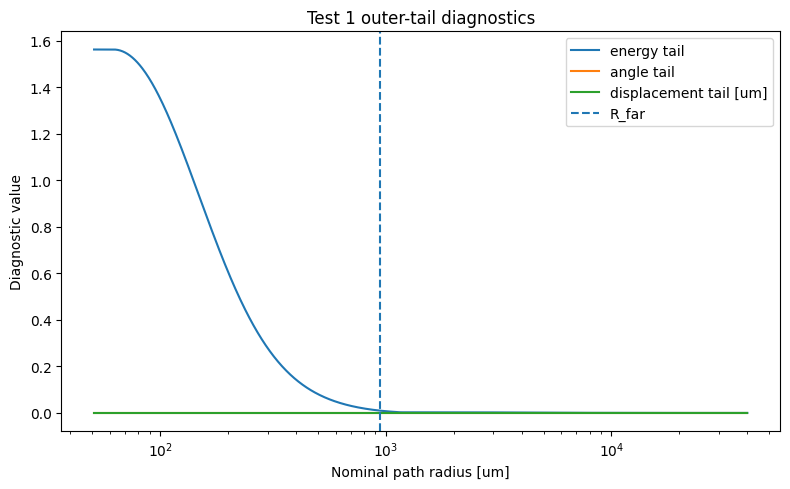

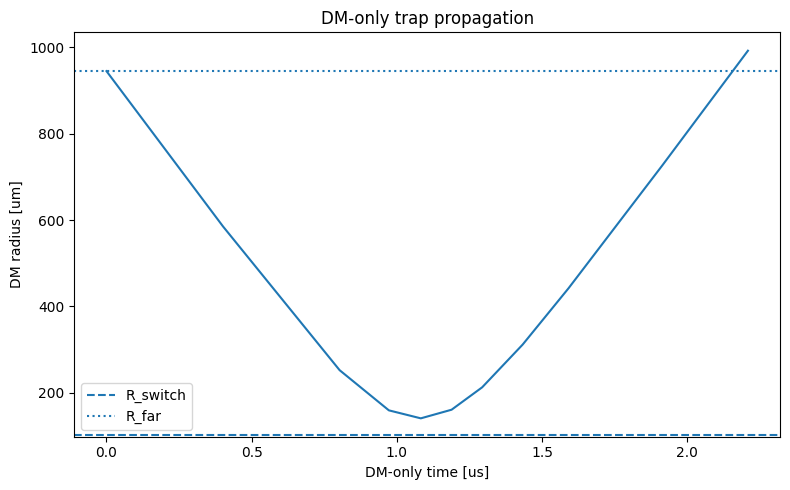


-------- Staged Simulation Summary --------
Radii:         R_far=892.220425 um  R_switch=90.680224 um  R_full=45.340112 um
Reach times:   t(R_far)=0.000000 us  t(R_switch)=nan us  t(R_full)=nan us  [time origin is the DM launch at R_far]
Outer-line diagnostic: nominal time from R_max to R_far=38.263077 us
Straight tail: status=straight_then_dm_only  v_far=1016.96 m/s  limiting=energy
DM only:      status=dm_only_escaped_without_switch  entered_switch=False  r_min=109.961 um  r_min/R_far=0.123245  runtime=0.421 s

-------- Initial and Final States --------
Positions are in um; velocities are in m/s.
DM initial at R_far:  x=[1.638982e-13, 5.463274e-14, 8.922204e+02]  v=[-1.868118e-13, -6.227060e-14, -1.016956e+03]
Ion initial:          x=[0., 0., 0.]  v=[0., 0., 0.]
Ion final:            not propagated because the full stage was not entered
DM final:             x=[-3.930399e-13, -5.068523e-13,  9.368314e+02]  v=[-1.696630e-13,  4.032221e-14,  1.017938e+03]

Overall status: stopped_afte

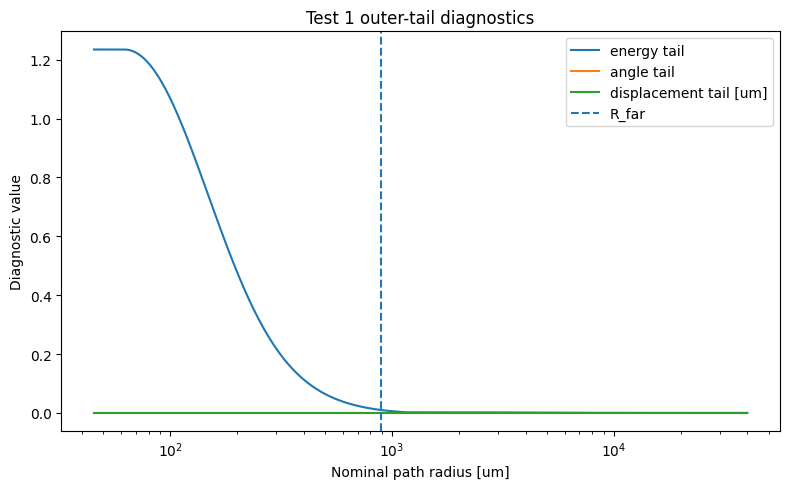

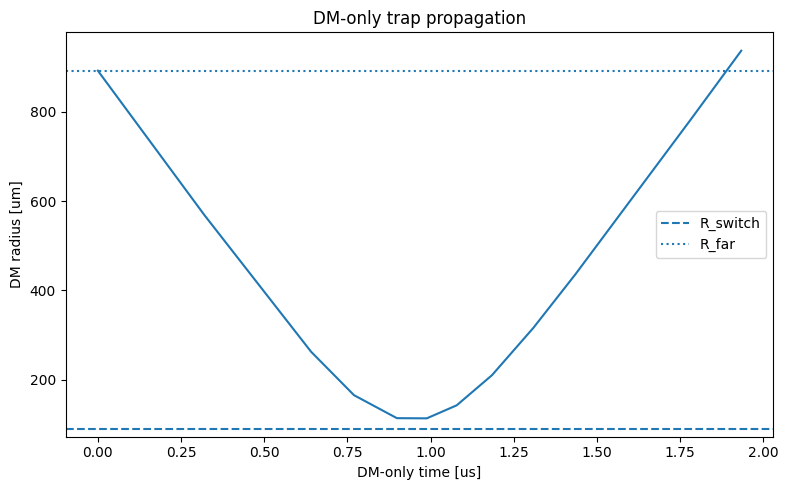


-------- Staged Simulation Summary --------
Radii:         R_far=848.316029 um  R_switch=81.611506 um  R_full=40.805753 um
Reach times:   t(R_far)=0.000000 us  t(R_switch)=0.805086 us  t(R_full)=1.410297 us  [time origin is the DM launch at R_far]
Outer-line diagnostic: nominal time from R_max to R_far=34.475430 us
Straight tail: status=straight_then_dm_only  v_far=1129.99 m/s  limiting=energy
DM only:      status=dm_only_entered_switch  entered_switch=True  r_min=81.612 um  r_min/R_far=0.0962041  runtime=0.198 s
Full coupled: status=full_timeout  reached_R_full=True  d_min=0.412 um  delta_E=1.214981e-19 J  runtime=144.273 s

-------- Initial and Final States --------
Positions are in um; velocities are in m/s.
DM initial at R_far:  x=[1.558331e-13, 5.194438e-14, 8.483160e+02]  v=[-2.075763e-13, -6.919211e-14, -1.129993e+03]
DM at R_switch:     x=[-3.994178e-14, -2.841223e-13,  8.161151e+01]  v=[-9.919840e-13, -2.876827e-12, -2.393265e+02]
Ion initial:          x=[0., 0., 0.]  v=[0., 

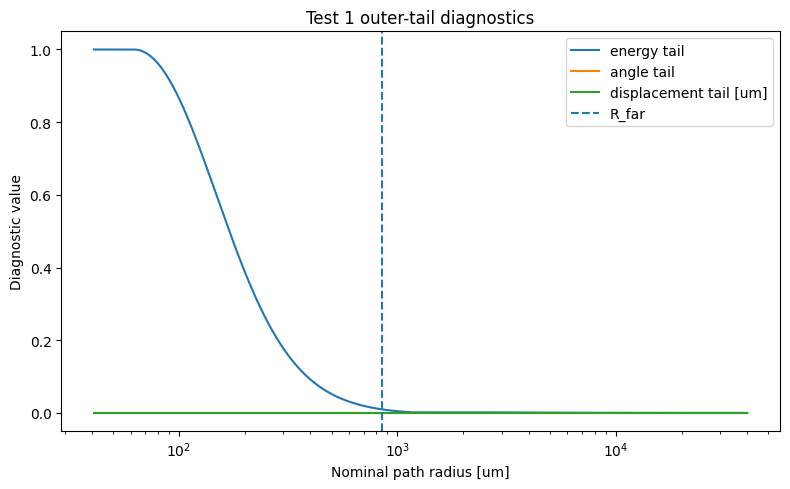

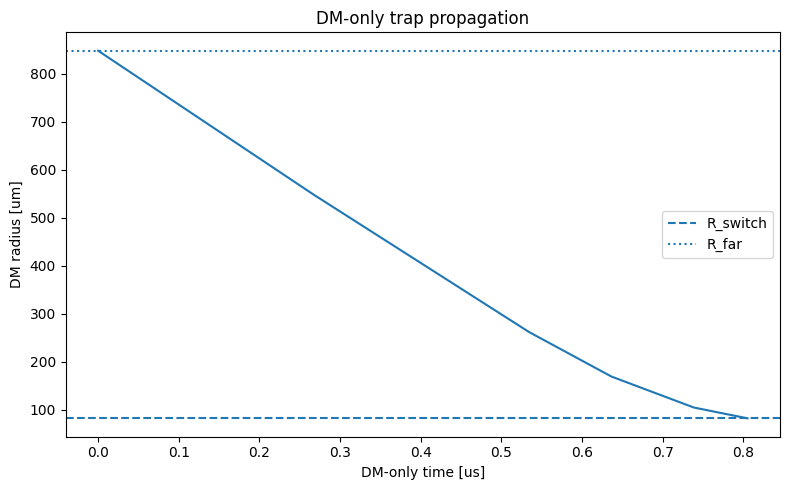

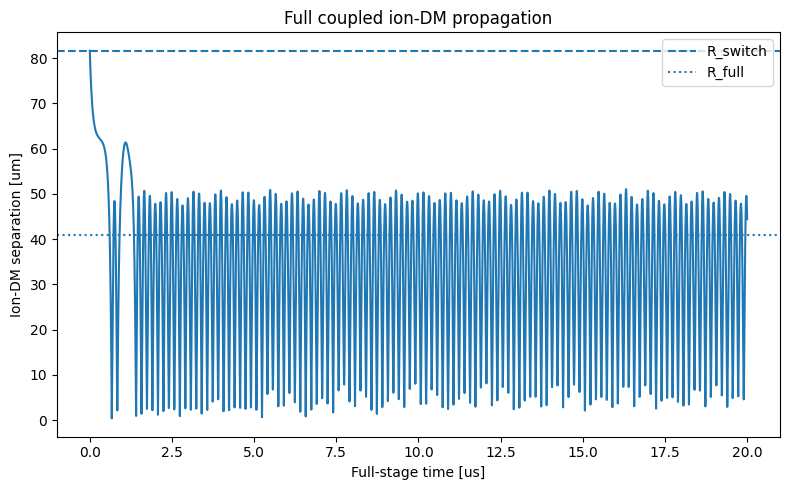

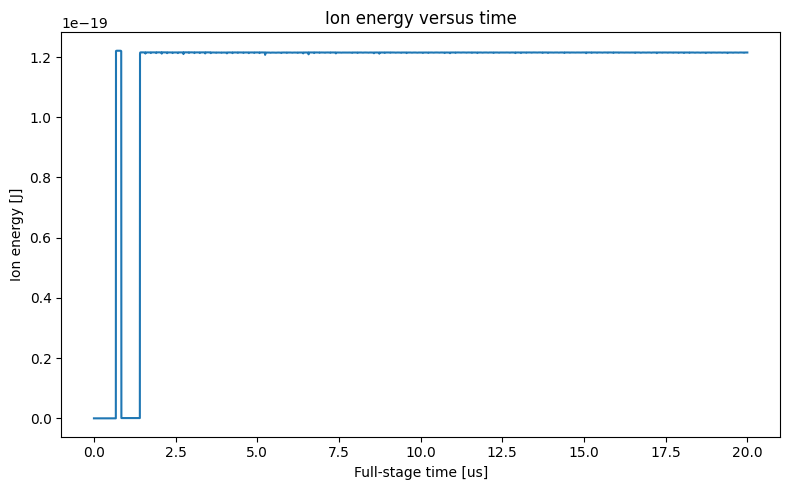

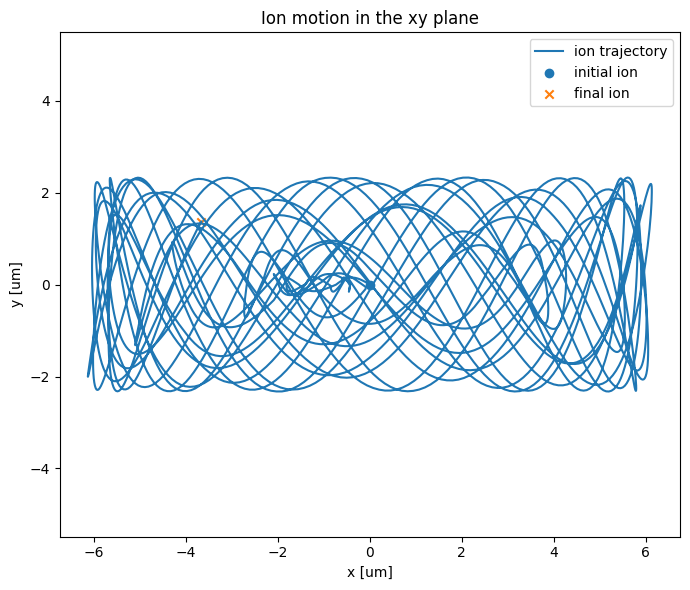

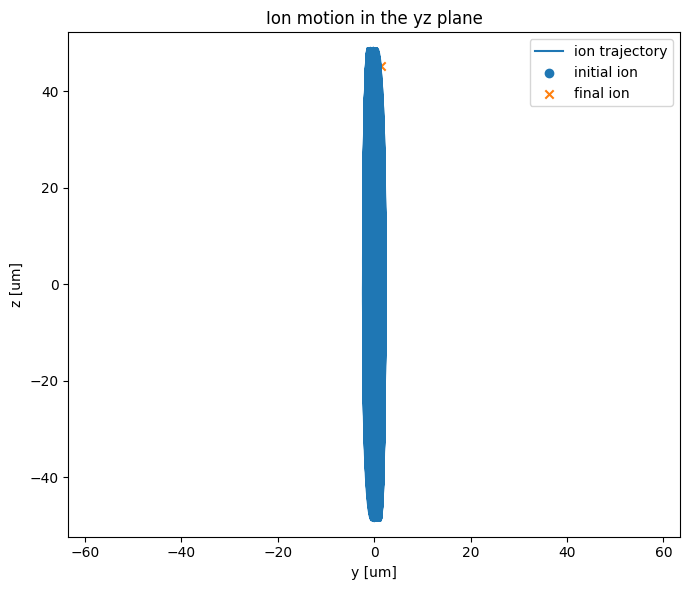

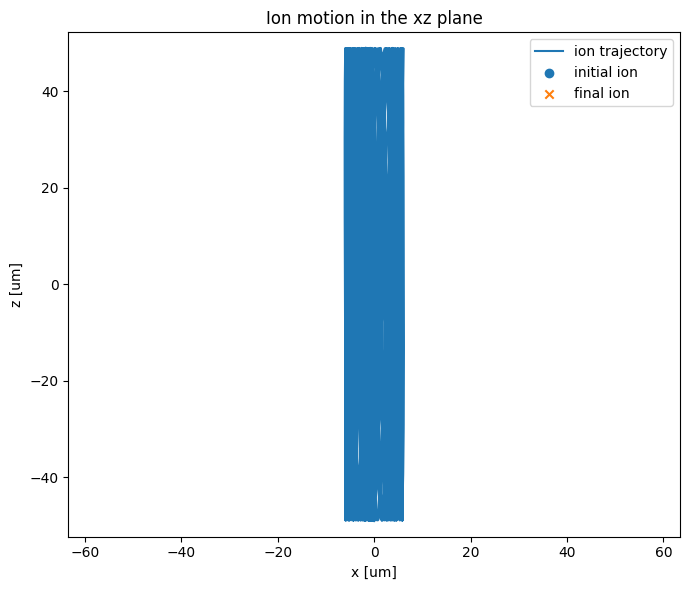

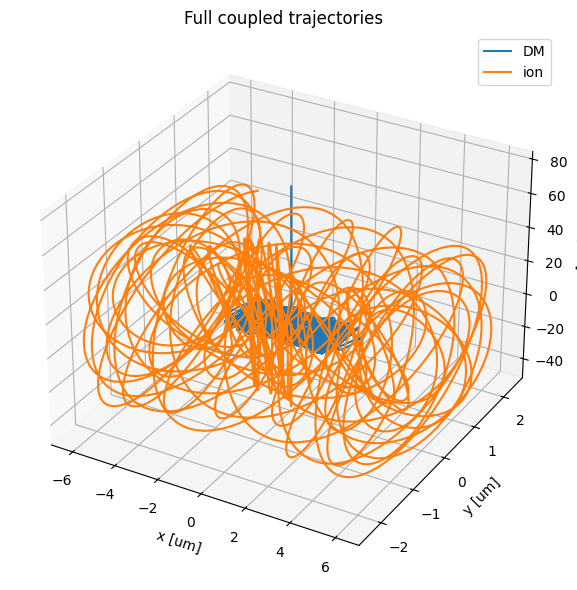


-------- Staged Simulation Summary --------
Radii:         R_far=811.324389 um  R_switch=74.191760 um  R_full=37.095880 um
Reach times:   t(R_far)=0.000000 us  t(R_switch)=0.668859 us  t(R_full)=0.736237 us  [time origin is the DM launch at R_far]
Outer-line diagnostic: nominal time from R_max to R_far=31.370912 us
Straight tail: status=straight_then_dm_only  v_far=1243.12 m/s  limiting=energy
DM only:      status=dm_only_entered_switch  entered_switch=True  r_min=74.192 um  r_min/R_far=0.0914452  runtime=0.403 s
Full coupled: status=reached_R_full_and_escaped  reached_R_full=True  d_min=0.130 um  delta_E=6.026326e-20 J  runtime=9.024 s

-------- Initial and Final States --------
Positions are in um; velocities are in m/s.
DM initial at R_far:  x=[1.490379e-13, 4.967929e-14, 8.113244e+02]  v=[-2.283583e-13, -7.611944e-14, -1.243125e+03]
DM at R_switch:     x=[ 4.270422e-14, -1.285994e-13,  7.419176e+01]  v=[-6.939846e-15, -9.055626e-13, -5.430384e+02]
Ion initial:          x=[0., 0., 

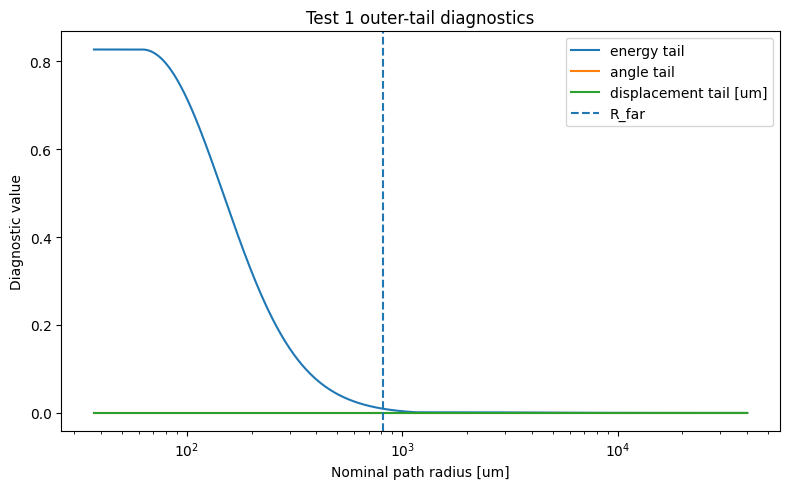

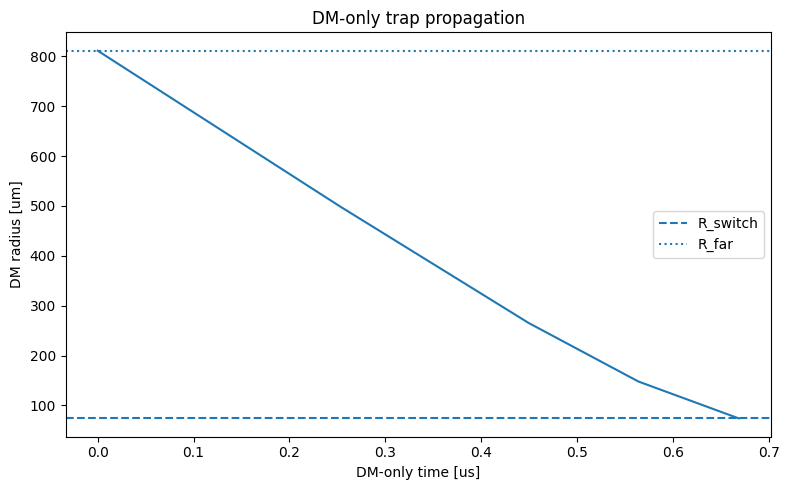

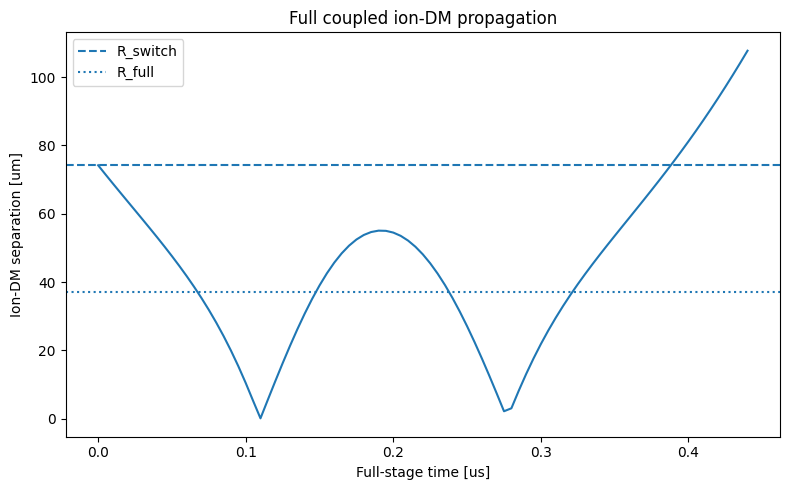

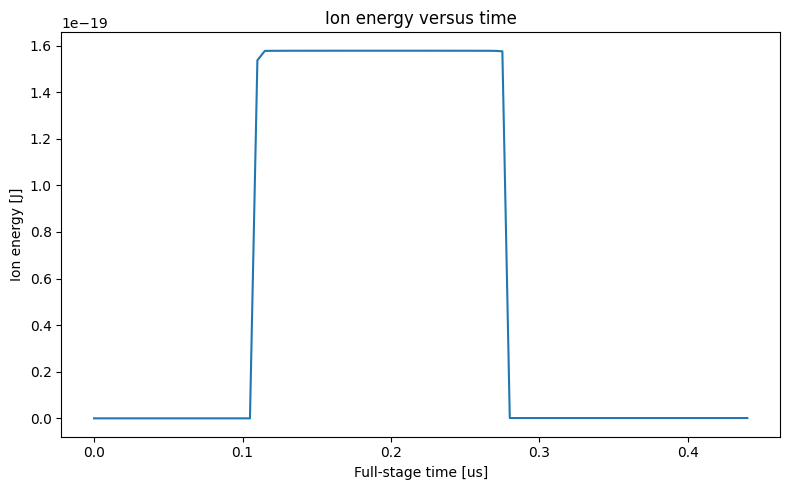

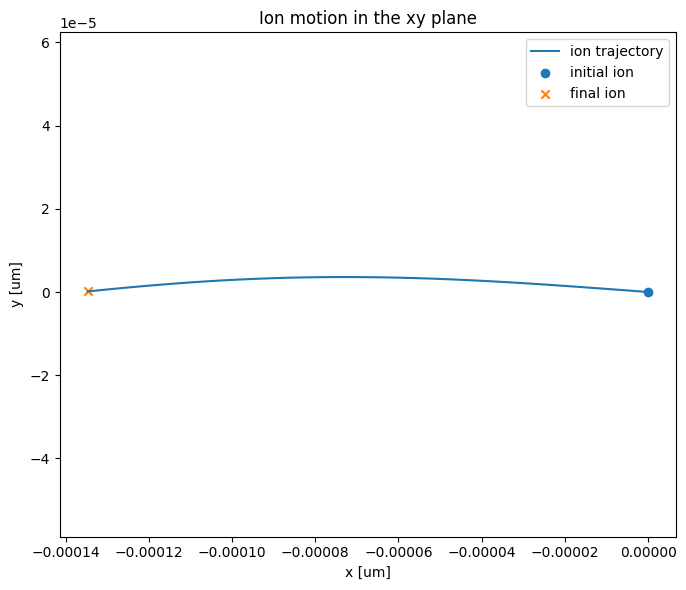

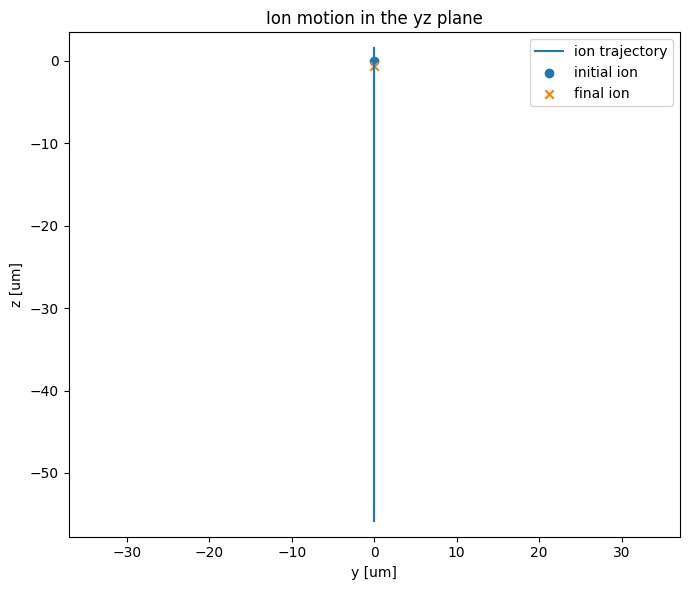

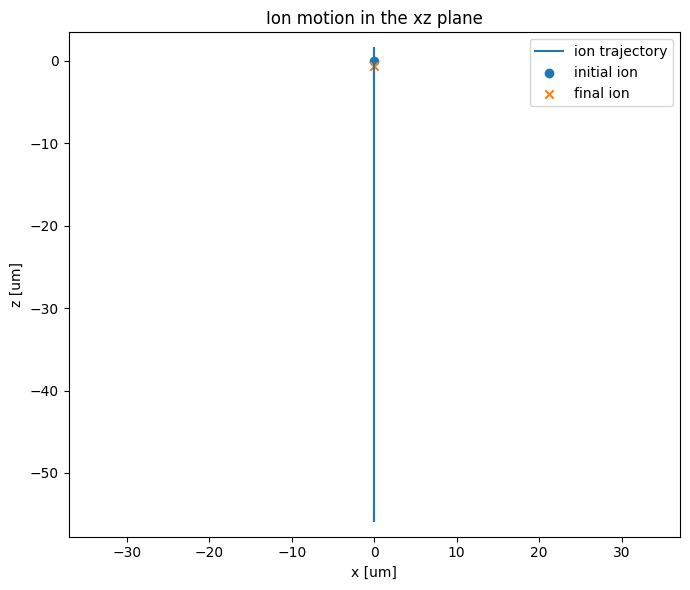

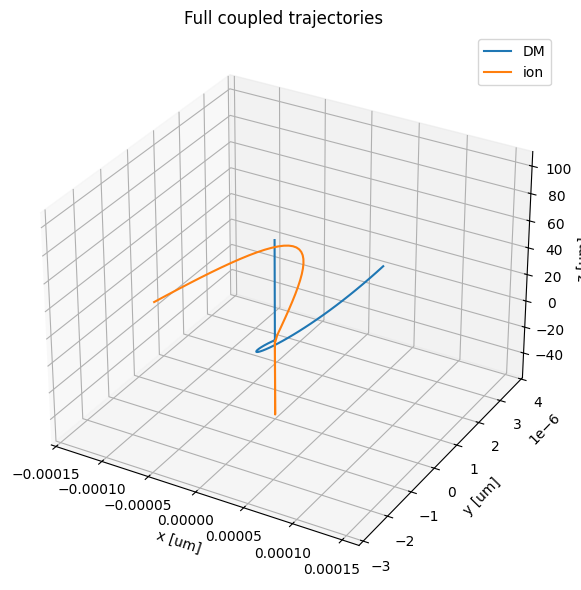


-------- Staged Simulation Summary --------
Radii:         R_far=772.857868 um  R_switch=68.008718 um  R_full=34.004359 um
Reach times:   t(R_far)=0.000000 us  t(R_switch)=0.573155 us  t(R_full)=0.616447 us  [time origin is the DM launch at R_far]
Outer-line diagnostic: nominal time from R_max to R_far=28.784896 us
Straight tail: status=straight_then_dm_only  v_far=1356.13 m/s  limiting=energy
DM only:      status=dm_only_entered_switch  entered_switch=True  r_min=68.009 um  r_min/R_far=0.0879964  runtime=0.393 s
Full coupled: status=reached_R_full_and_escaped  reached_R_full=True  d_min=0.586 um  delta_E=8.901890e-20 J  runtime=6.752 s

-------- Initial and Final States --------
Positions are in um; velocities are in m/s.
DM initial at R_far:  x=[1.419717e-13, 4.732390e-14, 7.728579e+02]  v=[-2.491171e-13, -8.303902e-14, -1.356130e+03]
DM at R_switch:     x=[1.690236e-14, 6.470761e-14, 6.800872e+01]  v=[-1.391066e-13,  6.927514e-14, -7.574044e+02]
Ion initial:          x=[0., 0., 0.]

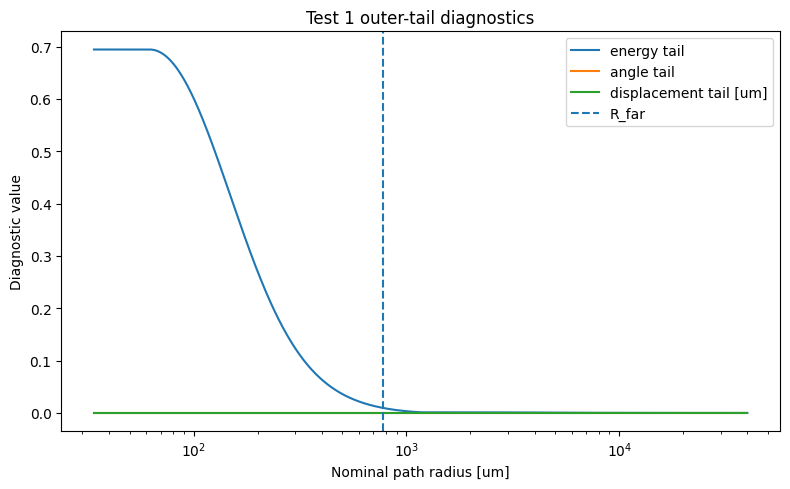

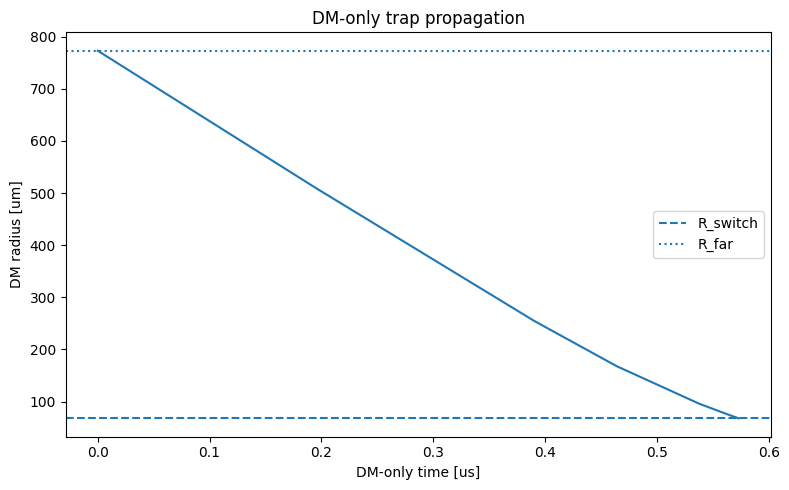

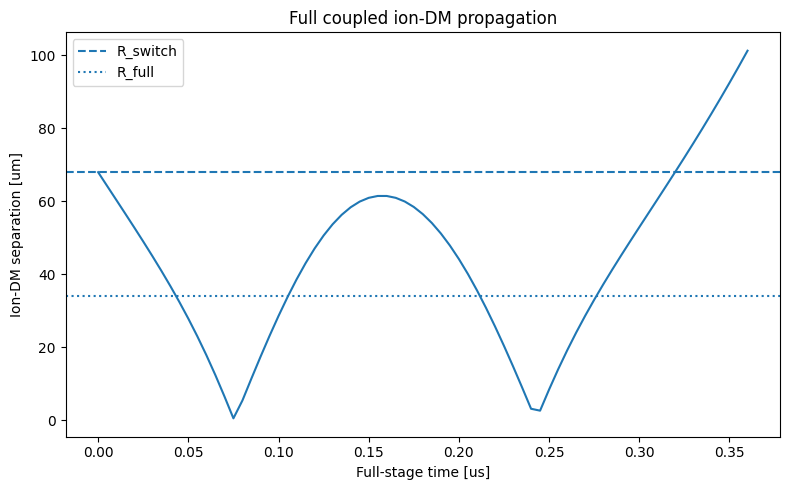

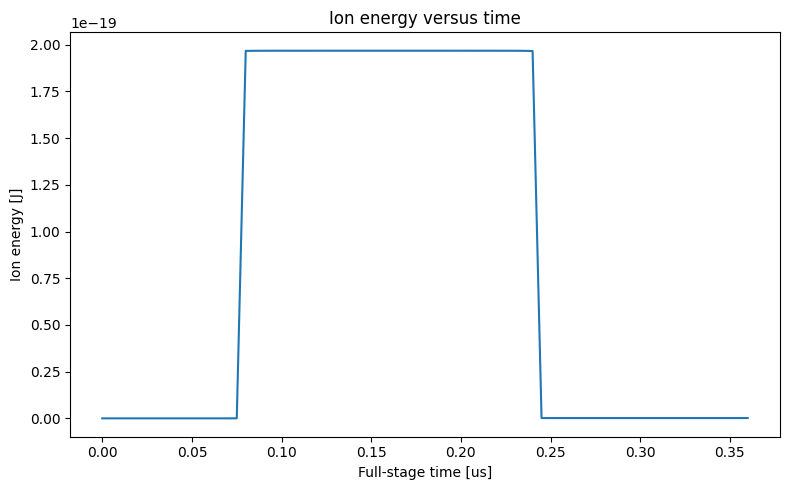

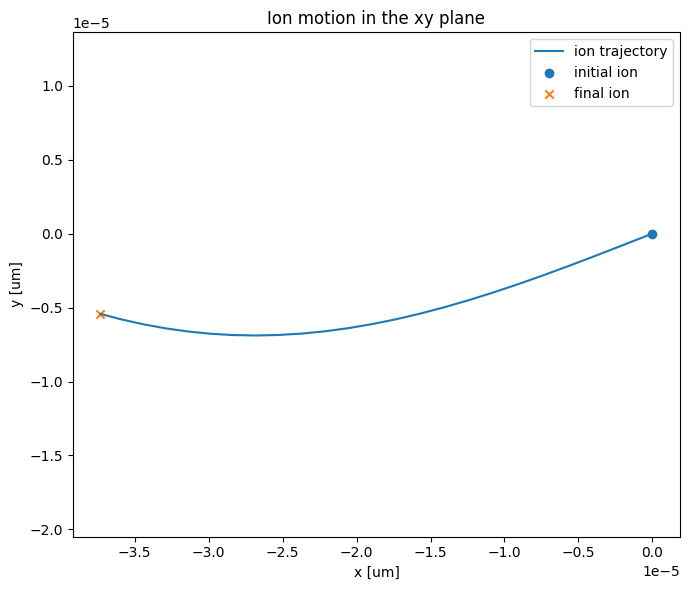

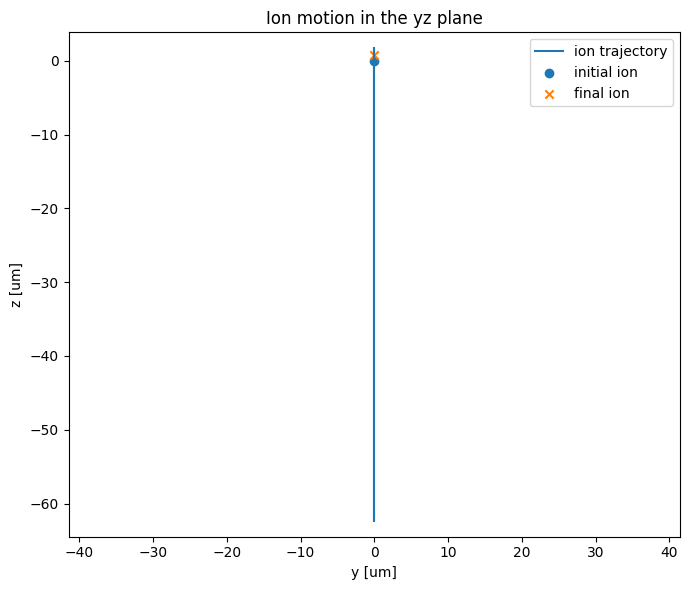

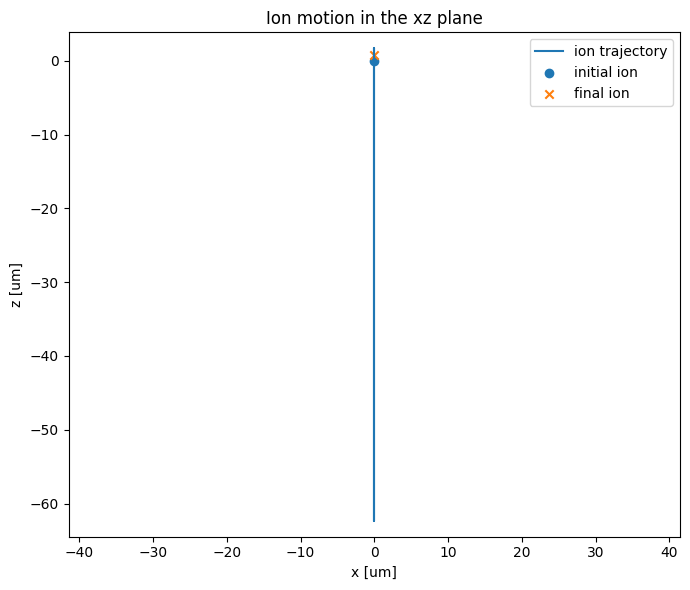

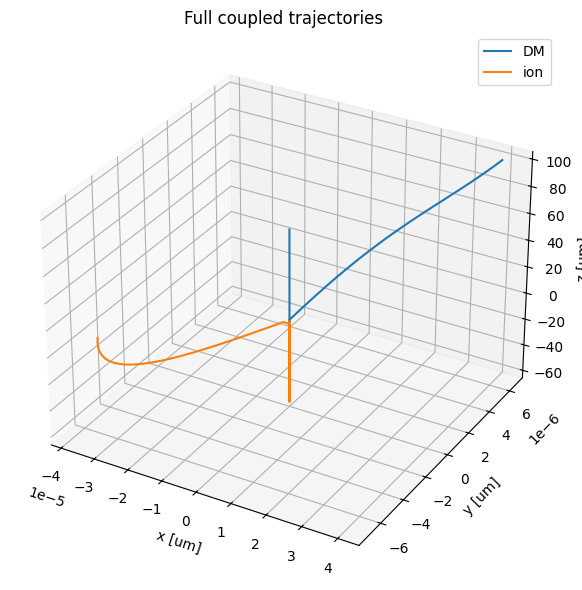

In [ ]:
# PE check:
PE_0 = potential_energy(r0,m_dm,eps)
print(f"PE at {r0} is {PE_0}J, which is {PE_0/K0*100}% of the kinetic energy.")
# Initial conditions
speed = np.sqrt(2*(escape_energy-PE_0)/m_dm)
b = 0
R_start = 40e-3
r0 = [b,0,R_start]
v0 = [0,0,-speed]
# Run simulation
# Parameters
## Solver
t_min = 0
t_after_arr = [1e-6]
speed_arr = speed*np.array([0.8,0.9,1,1.1,1.2]) 
for speed in speed_arr:
    for t_after in t_after_arr:
        t_arrival = R_start / speed
        t_max = t_arrival + t_after
        ## Trajectory
        theta, alpha, psi = 3*np.pi/2, np.pi/2, 0
        single_simulation(m_dm=m_dm,eps=eps,theta=theta,alpha=alpha,psi=psi,R_max=R_start,b=b,plot=True,speed=speed)